In [1]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 74.2 MB/s eta 0:00:00


In [287]:
import copy
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import scipy.sparse as sp
import matplotlib.gridspec as gs
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATv2Conv, APPNP, JumpingKnowledge, LabelPropagation
from torch_geometric.utils import from_scipy_sparse_matrix, to_undirected, remove_self_loops
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from collections import Counter
import platform
import time

In [288]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [289]:
SEED=25
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [290]:
print(f"OS = {platform.system()} {platform.release()}")
print(f"processor = {platform.system()}")

OS = Linux 6.6.113+
processor = Linux


In [291]:
print(f"Pytorch Version = {torch.__version__}")

Pytorch Version = 2.10.0+cpu


In [292]:
START_TIME = time.time()

# Loading Data and Validation

In [293]:
train_val_df = pd.read_csv('train_val_labeled.csv')
test_df = pd.read_csv('test_features_only.csv')
adj_df = pd.read_csv('adjacency_matrix.csv')

In [294]:
print(f"Train Val shape  = {train_val_df.shape}")
print(f"Test shape = {test_df.shape}")
print(f"Adj shape = {adj_df.shape}")

Train Val shape  = (640, 1435)
Test shape = (1000, 1434)
Adj shape = (2707, 2708)


In [295]:
train_val_df.head()

,word_0,word_1,word_2,word_3,word_4,word_5,word_6,word_7,word_8,word_9,...,word_1425,word_1426,word_1427,word_1428,word_1429,word_1430,word_1431,word_1432,target,id
0,0.000000,0.254512,0.000000,0.000000,0.396139,0.189993,0.000000,0.000000,0.000000,0.062381,...,0.619050,0.000000,0.266029,0.518465,0.000000,1.000000,0.954291,0.671058,3,0
1,0.000000,0.412502,0.000000,0.000000,0.000000,0.078024,0.073060,0.359106,0.000000,0.365384,...,0.000000,0.671789,0.647814,0.000000,0.000000,0.195134,0.252293,0.000000,4,1
2,0.038983,0.128888,0.266918,0.671799,0.432882,0.255227,0.000000,0.000000,0.352532,0.065281,...,0.596002,0.000000,0.000000,0.000000,0.000000,0.090133,0.000000,0.000000,4,2
3,0.000000,0.000000,0.454025,0.000000,0.000000,0.346009,0.093135,0.507108,0.502581,0.000000,...,0.333688,0.000000,0.484122,0.012767,0.484841,0.247734,0.787112,0.370596,0,3
4,0.236430,0.000000,0.468288,0.565917,0.000000,0.000000,0.619783,0.000000,0.000000,0.010897,...,0.012419,0.000000,0.289624,0.267483,0.034960,0.147601,0.000000,0.000000,3,4


In [296]:
feat_cols = [c for c in train_val_df.columns if c.startswith('word_')]

In [297]:
labeled_ids = train_val_df['id'].values
labeled_feats  = train_val_df[feat_cols].values.astype(np.float32)
labeled_labels = train_val_df['target'].values.astype(np.int64)

In [298]:
NUM_CLASSES = len(np.unique(labeled_labels))

In [299]:
test_df.head(2)

,word_0,word_1,word_2,word_3,word_4,word_5,word_6,word_7,word_8,word_9,...,word_1424,word_1425,word_1426,word_1427,word_1428,word_1429,word_1430,word_1431,word_1432,id
0,0.000000,0.838669,0.158768,0.333351,0.551831,0.10644,0.584553,0.862779,0.590877,0.000000,...,0.704692,0.000000,0.049254,0.0,0.362039,0.36354,0.0,0.858049,0.204279,1708
1,0.906611,0.000000,0.622145,0.122846,0.000000,0.00000,0.000000,0.418310,0.135362,0.081961,...,0.065883,0.391594,0.000000,0.0,0.000000,1.00000,0.0,0.527566,0.000000,1709


In [300]:
test_ids = test_df['id'].values
test_feats = test_df[feat_cols].values.astype(np.float32)

In [301]:
train_ids = labeled_ids[:140]
val_ids = labeled_ids[140:]

In [302]:
print(f"Labeled node IDs = {labeled_ids.min()}  - {labeled_ids.max()}")
print(f"Labeled node IDs = {test_ids.min()}  - {test_ids.max()}")

Labeled node IDs = 0  - 639
Labeled node IDs = 1708  - 2707


In [303]:
np.bincount(labeled_labels[:140]).tolist()

[20, 20, 20, 20, 20, 20, 20]

In [304]:
print(f"train split size = {len(train_ids)} , {np.bincount(labeled_labels[:140]).tolist()} split per class")
print(f'val split size = {len(val_ids)}')
print(f'test split size = {len(test_ids)}')

train split size = 140 , [20, 20, 20, 20, 20, 20, 20] split per class
val split size = 500
test split size = 1000


In [305]:
NUM_NODES = adj_df.shape[1]

In [306]:
full_features = np.zeros((NUM_NODES,len(feat_cols)),dtype=np.float32)
full_labels= np.full(NUM_NODES,-1,dtype=np.int64)
full_features.shape, full_labels.shape

((2708, 1433), (2708,))

In [307]:
for i, nid in enumerate(labeled_ids):
  full_features[nid] = labeled_feats[i]
  full_labels[nid] = labeled_labels[i]

In [308]:
for i,nid in enumerate(test_ids):
  full_features[nid] = test_feats[i]

In [309]:
all_feat_ids = np.concatenate([labeled_ids,test_ids])
g_ids = sorted(set(range(NUM_NODES)) - set(all_feat_ids))

In [310]:
print(f"Full Feature matrix shape = {full_features.shape}")
print(f"Nodes with features = {len(all_feat_ids)}")
print(f'Nodes without features = {len(g_ids)}')

Full Feature matrix shape = (2708, 1433)
Nodes with features = 1640
Nodes without features = 1068


In [311]:
adj_raw = adj_df.values.astype(np.float32)
f"Adjacency matrix shape = {adj_raw.shape}"

'Adjacency matrix shape = (2707, 2708)'

In [312]:
adj_full = np.zeros((NUM_NODES,NUM_NODES),dtype=np.float32)
adj_full[:adj_raw.shape[0],:adj_raw.shape[1]] = adj_raw

In [313]:
adj_sym = np.maximum(adj_full,adj_full.T)
np.fill_diagonal(adj_sym,0)

In [314]:
print(f"Fixed adjancecy matrix shape = {adj_sym.shape}")
print(f"Total edges undirected = {adj_sym.sum() / 2}")

Fixed adjancecy matrix shape = (2708, 2708)
Total edges undirected = 10367.0


# EDA

In [315]:
G_nx = nx.from_numpy_array(adj_sym)
degrees = [d  for _,d in G_nx.degree()]
comps = sorted(nx.connected_components(G_nx),key=len,reverse=True)
cc_sizes = [len(c) for c in comps]

In [316]:
print(f"Graph Topology Summary:")
print(f"{'Num nodes'} =  {G_nx.number_of_nodes()}")
print(f"{'Num edges'} = {G_nx.number_of_edges()}")
print(f"{'Self loops'} = {nx.number_of_selfloops(G_nx)}")
print(f"{'Is connected'} = {nx.is_connected(G_nx)}")
print(f"{'Num connected components'} = {len(comps)}")
print(f"{'Largest component size'} = {cc_sizes[0]}")
print(f"{'Min degree'} = {min(degrees)}")
print(f"{'Max degree'} = {max(degrees)}")
print(f"{'Mean degree'} = {np.mean(degrees):.2f}")
print(f"{'Median degree'} = {np.median(degrees):.0f}")

Graph Topology Summary:
Num nodes =  2708
Num edges = 10367
Self loops = 0
Is connected = False
Num connected components = 7
Largest component size = 2702
Min degree = 0
Max degree = 173
Mean degree = 7.66
Median degree = 6


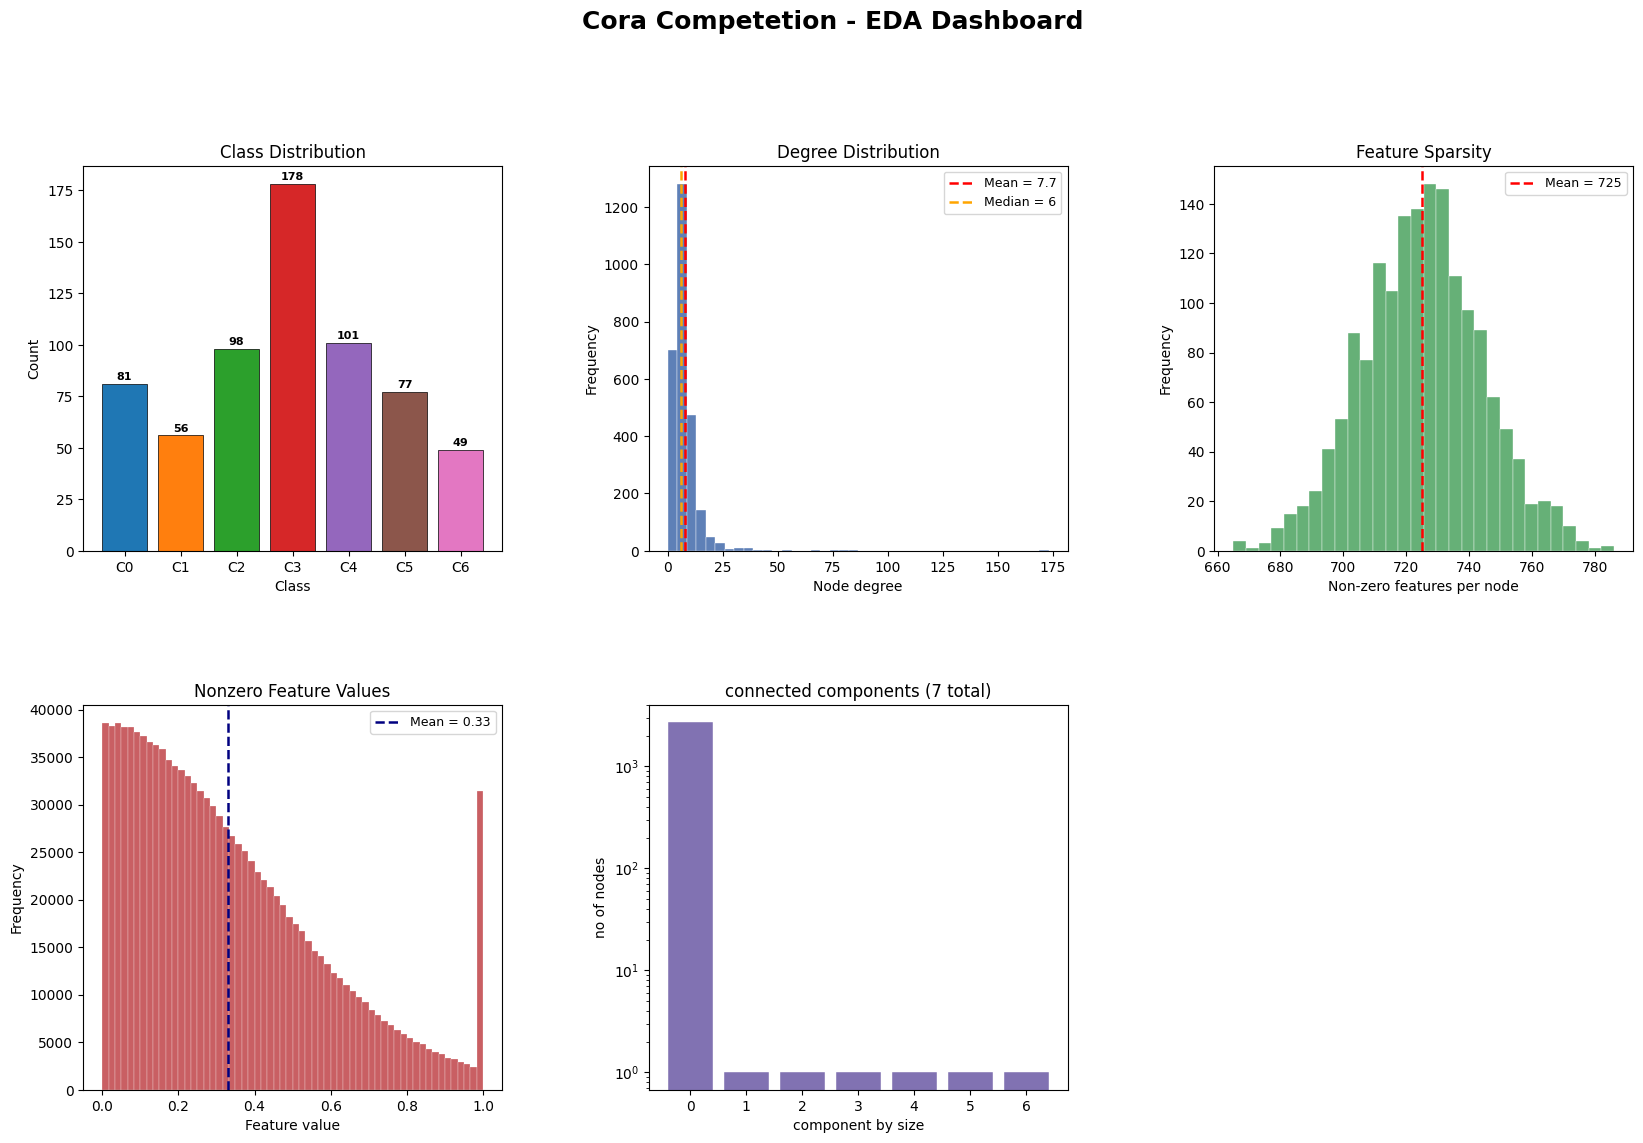

In [317]:
fig = plt.figure(figsize=(20,12))
fig.suptitle("Cora Competetion - EDA Dashboard",fontsize=18, fontweight='bold',y=1.01)
g = gs.GridSpec(2,3,figure=fig,hspace=0.4,wspace=0.35)
palette = sns.color_palette('tab10',NUM_CLASSES)
class_counts = pd.Series(labeled_labels).value_counts().sort_index()
ax1 = fig.add_subplot(g[0, 0])
bars = ax1.bar(class_counts.index, class_counts.values,
               color=palette, edgecolor="black", linewidth=0.5)
ax1.set_xticks(range(7))
ax1.set_xticklabels([f"C{i}" for i in range(7)])
ax1.set_xlabel("Class")
ax1.set_ylabel("Count")
ax1.set_title("Class Distribution")
for bar, cnt in zip(bars, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1, str(cnt),
             ha="center", va="bottom", fontsize=8, fontweight="bold")


ax2 = fig.add_subplot(g[0, 1])
ax2.hist(degrees, bins=40, color="#4C72B0", edgecolor="white",
         linewidth=0.3, alpha=0.9)
ax2.axvline(np.mean(degrees),   color="red",    linestyle="--",
            lw=1.8, label=f"Mean = {np.mean(degrees):.1f}")
ax2.axvline(np.median(degrees), color="orange", linestyle="--",
            lw=1.8, label=f"Median = {np.median(degrees):.0f}")
ax2.set_xlabel("Node degree")
ax2.set_ylabel("Frequency")
ax2.set_title("Degree Distribution")
ax2.legend(fontsize=9)

ax3 = fig.add_subplot(g[0, 2])
nonzero_counts = np.count_nonzero(full_features[all_feat_ids], axis=1)
ax3.hist(nonzero_counts, bins=30, color="#55A868", edgecolor="white",
         linewidth=0.3, alpha=0.9)
ax3.axvline(nonzero_counts.mean(), color="red", linestyle="--",
            lw=1.8, label=f"Mean = {nonzero_counts.mean():.0f}")
ax3.set_xlabel("Non-zero features per node")
ax3.set_ylabel("Frequency")
ax3.set_title("Feature Sparsity")
ax3.legend(fontsize=9)

ax4 = fig.add_subplot(g[1, 0])
nonzero_vals = full_features[all_feat_ids].flatten()
nonzero_vals = nonzero_vals[nonzero_vals > 0]
ax4.hist(nonzero_vals, bins=60, color="#C44E52", edgecolor="white",
         linewidth=0.2, alpha=0.9)
ax4.set_xlabel("Feature value")
ax4.set_ylabel("Frequency")
ax4.set_title("Nonzero Feature Values")
ax4.axvline(nonzero_vals.mean(), color="navy", linestyle="--",
            lw=1.8, label=f"Mean = {nonzero_vals.mean():.2f}")
ax4.legend(fontsize=9)
ax5 = fig.add_subplot(g[1, 1])
ax5.bar(range(min(20, len(cc_sizes))), cc_sizes[:20],
        color="#8172B2", edgecolor="white", linewidth=0.3)
ax5.set_xlabel("component by size")
ax5.set_ylabel("no of nodes")
ax5.set_title(f"connected components ({len(comps)} total)")
ax5.set_yscale("log")
plt.show()

In [318]:
class_counts

,count
0,81
1,56
2,98
3,178
4,101
5,77
6,49


In [319]:
tsne = TSNE(n_components=2,perplexity=30,n_iter=1000, random_state=SEED,verbose=0)
X_tsne = tsne.fit_transform(labeled_feats)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [320]:
CLASS_NAMES = [
    "Case Based",
    "Genetic Algorithms",
    "Neural Networks",
    "Probabilistic Methods",
    "Reinforcement Learning",
    "Rule Learning",
    "Theory",
]


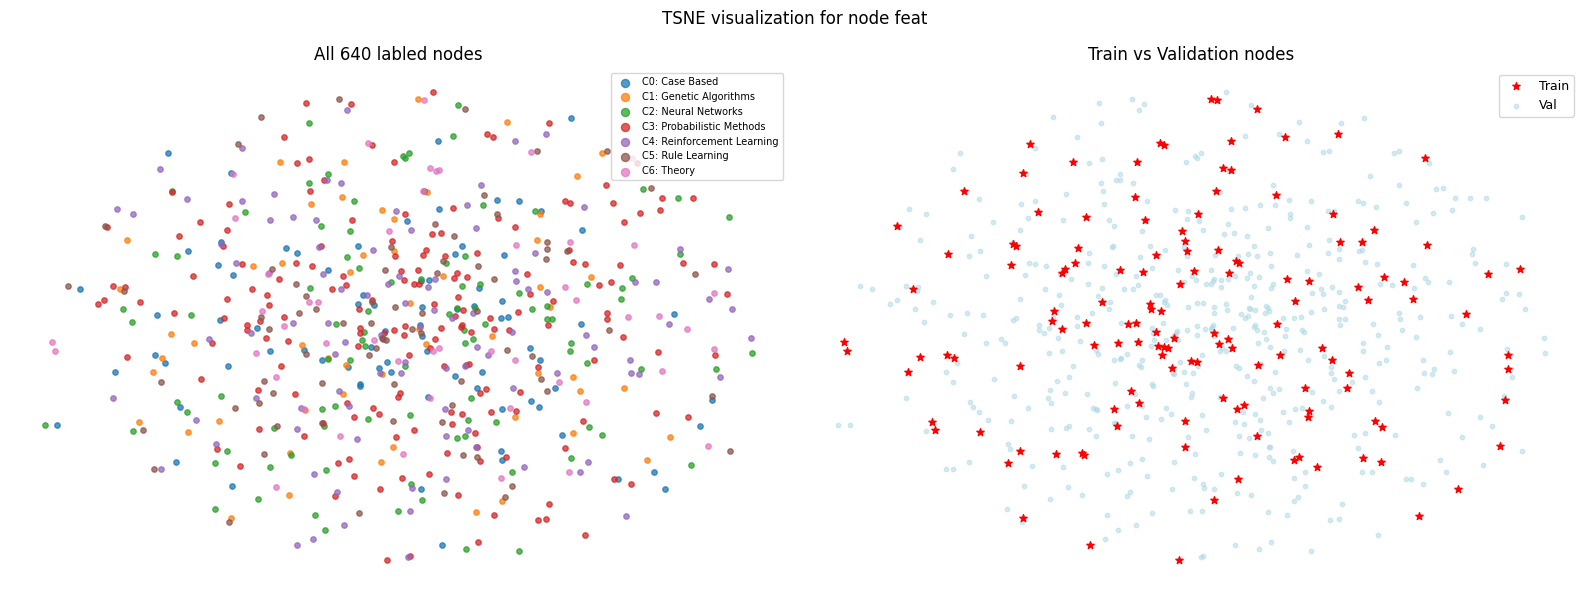

In [321]:
fig,axes = plt.subplots(1,2,figsize=(16,6))
fig.suptitle('TSNE visualization for node feat')
ax = axes[0]
for cls in range(NUM_CLASSES):
  mask = labeled_labels == cls
  ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],c=[palette[cls]], label=f"C{cls}: {CLASS_NAMES[cls]}",s=15, alpha=0.75)
ax.set_title("All 640 labled nodes")
ax.legend(fontsize=7,markerscale=1.5,loc='upper right')
ax.axis('off')

ax = axes[1]
ax.scatter(X_tsne[:140,0],X_tsne[:140,1],c='red',s=30,alpha=1.0,label="Train",marker="*",zorder=3)
ax.scatter(X_tsne[140:,0],X_tsne[140:,1],c='lightblue',s=10, alpha=0.5, label="Val")
ax.set_title("Train vs Validation nodes")
ax.legend(fontsize=9)
ax.axis('off')
plt.tight_layout()
plt.show()

In [322]:
class_feat_means = []
for cls in range(NUM_CLASSES):
  mask = labeled_labels == cls
  class_feat_means.append(labeled_feats[mask].mean(axis=0))
class_feat_means = np.array(class_feat_means)

In [323]:
feat_disc = class_feat_means.var(axis=0)
top_feat_indices = np.argsort(feat_disc)[::-1][:30]

In [324]:
top_feat_indices

array([1263,  495,  581,  507, 1209,  750,    4,  774,   19, 1132,  814,
       1005,   99,  729, 1170, 1149,  758,  544,  725, 1177,  874, 1199,
       1259, 1203, 1151,  485,  299, 1265,  978,  205])

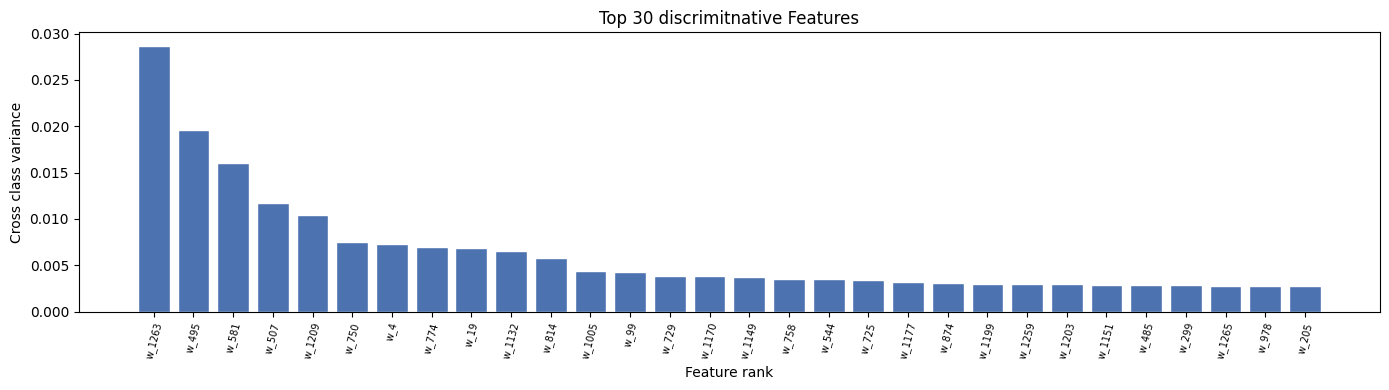

In [325]:
fig,ax = plt.subplots(figsize=(14,4))
ax.bar(range(30), feat_disc[top_feat_indices], color='#4C72B0', edgecolor='white')
ax.set_xlabel("Feature rank")
ax.set_ylabel('Cross class variance')
ax.set_title('Top 30 discrimitnative Features')
ax.set_xticks(range(30))
ax.set_xticklabels([f'w_{i}' for i in top_feat_indices],rotation=75,fontsize=7)
plt.tight_layout()
plt.show()

# Graph Construction

In [326]:
adj_sparse = sp.coo_matrix(adj_sym)
edge_index,_ = from_scipy_sparse_matrix(adj_sparse)
edge_index = to_undirected(edge_index, num_nodes=NUM_NODES)
edge_index,_= remove_self_loops(edge_index)

In [327]:
train_mask = torch.zeros(NUM_NODES, dtype=torch.bool)
val_mask = torch.zeros(NUM_NODES, dtype=torch.bool)
test_mask = torch.zeros(NUM_NODES, dtype=torch.bool)

In [328]:
train_mask[torch.LongTensor(train_ids)] = True
val_mask[torch.LongTensor(val_ids)] = True
test_mask[torch.LongTensor(test_ids)] = True

In [329]:
data = Data(x=torch.FloatTensor(full_features),y=torch.LongTensor(full_labels),edge_index=edge_index,train_mask=train_mask,val_mask=val_mask,test_mask=test_mask)

In [330]:
data.test_ids = torch.LongTensor(test_ids)

In [331]:
print(f'data object = {data}')
print(f'Edge Index shape = {edge_index.shape} -> {edge_index.shape[1]} directed edges')
print(f'Train -> {train_mask.sum()} | Val -> {val_mask.sum()} | Test -> {test_mask.sum()}')

data object = Data(x=[2708, 1433], edge_index=[2, 20734], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708], test_ids=[1000])
Edge Index shape = torch.Size([2, 20734]) -> 20734 directed edges
Train -> 140 | Val -> 500 | Test -> 1000


In [332]:
all_labeled_y = data.y[train_mask | val_mask]
counts = torch.bincount(all_labeled_y, minlength=NUM_CLASSES).float()
class_weights = counts.sum() / (NUM_CLASSES * counts)

In [333]:
data.class_weights = class_weights

In [334]:
for i in range(NUM_CLASSES):
  print(f"Class {i} -> counts = {int(counts[i])} weight = {class_weights[i]:.3f} ")

Class 0 -> counts = 81 weight = 1.129 
Class 1 -> counts = 56 weight = 1.633 
Class 2 -> counts = 98 weight = 0.933 
Class 3 -> counts = 178 weight = 0.514 
Class 4 -> counts = 101 weight = 0.905 
Class 5 -> counts = 77 weight = 1.187 
Class 6 -> counts = 49 weight = 1.866 


# Feature Engineering

In [335]:
scaler_ref = StandardScaler()
X_ref = scaler_ref.fit_transform(full_features)
pca_ref = PCA(n_components=512,random_state=SEED)
pca_ref.fit(X_ref)
cumvar = np.cumsum(pca_ref.explained_variance_ratio_)

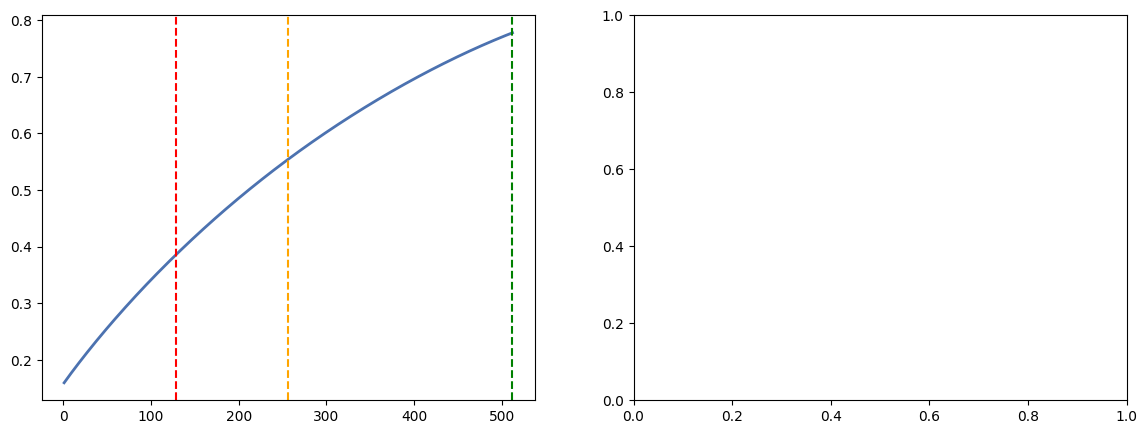

In [336]:
fig,axes =  plt.subplots(1,2,figsize=(14,5))
ax = axes[0]
ax.plot(range(1,513),cumvar,color='#4C72B0',linewidth=2)
for k,col in [(128,'red'), (256,'orange'),(512,'green')]:
  ax.axvline(k,color=col,linestyle="--",linewidth=1.5,label=f"k={k}:{cumvar[k-1]:.1%}")

In [337]:
def make_denoised_data(base_data,n_components):
  X = base_data.x.numpy()
  scaler = StandardScaler()
  X_scaled = scaler.fit_transform(X)
  pca = PCA(n_components=n_components,random_state=SEED)
  X_low = pca.fit_transform(X_scaled).astype(np.float32)
  new_data = copy.copy(base_data)
  new_data.x = torch.FloatTensor(X_low)
  return new_data

# MODELS

In [338]:
class GCN(nn.Module):
  def __init__(self,in_dim,hidden_dim,out_dim=7,dropout=0.5):
    super().__init__()
    self.dropout = dropout
    self.conv1 = GCNConv(in_dim,hidden_dim,cached=True,normalize=True)
    self.bn1 = nn.BatchNorm1d(hidden_dim)
    self.conv2 = GCNConv(hidden_dim,out_dim,cached=True,normalize=True)
  def forward(self,x,edge_index):
    x = self.conv1(x,edge_index)
    x = self.bn1(x)
    x = F.relu(x)
    x = F.dropout(x,p=self.dropout,training=self.training)
    x = self.conv2(x,edge_index)
    return x
  def reset_parameters(self):
    self.conv1.reset_parameters()
    self.conv2.reset_parameters()
    self.bn1.reset_paramteres()

In [339]:
def train(model,data,optimizer,class_weights):
  model.train()
  optimizer.zero_grad()
  logits = model(data.x,data.edge_index)
  loss = F.cross_entropy(
      logits[data.train_mask],
      data.y[data.train_mask],
      weight = class_weights
  )
  loss.backward()
  optimizer.step()
  return loss.item()

In [340]:
@torch.no_grad()
def validate(model,data):
  model.eval()
  logits = model(data.x,data.edge_index)
  probs = F.softmax(logits,dim=1)
  preds = logits.argmax(dim=1)
  val_acc = (preds[data.val_mask] == data.y[data.val_mask]).float().mean().item()
  return val_acc, probs.cpu()


In [341]:
def fit_model(model,data,epochs=500,lr=0.005,weight_decay=5e-4, patience=80, label="model",v=True):
  data = data.to(device)
  model = model.to(device)
  cw = data.class_weights.to(device)
  optimizer = torch.optim.Adam(model.parameters(),lr=lr,weight_decay=weight_decay)
  scheduler = CosineAnnealingLR(optimizer,T_max=epochs,eta_min=1e-5)
  best_val_acc = 0.0
  best_state = None
  patience_ctr = 0
  history = {"loss":[],"val_acc":[]}
  t_start = time.time()
  for epoch in range(1,epochs+1):
    loss = train(model,data,optimizer,cw)
    val_acc,_ = validate(model,data)
    scheduler.step()
    history['loss'].append(loss)
    history['val_acc'].append(val_acc)
    if val_acc > best_val_acc:
      best_val_acc = val_acc
      best_state = copy.deepcopy(model.state_dict())
      patience_ctr = 0

    else:
      patience_ctr += 1

    if patience_ctr >= patience:
      print(f"Early stopping at epoch = {epoch}")
      print(f'Best Val accuracy = {best_val_acc:.4f}')
      break

    if epoch % 100 == 0:
      print(f"epoch = {epoch} | loss = {loss:.4f} | val acc = {val_acc}")


  elapsed = time.time() - t_start
  model.load_state_dict(best_state)
  model.eval()
  return model, best_val_acc, history, elapsed

In [342]:
HP_RESULTS = []
hp_run_count = 0
for n_comp in [128, 256, 512]:
  hp_run_count += 1
  probe_data = make_denoised_data(data,n_comp)
  probe_model = GCN(in_dim=n_comp,hidden_dim=256,dropout=0.7)
  t0 = time.time()
  probe_model,acc,history,_ = fit_model(probe_model,probe_data,epochs=400,lr=0.01,patience=40,label=f"GCN-probe-k{n_comp}")
  elapsed = time.time() - t0
  logs = {
      "run":hp_run_count,
      "pca_k":n_comp,
      'model':"GCN",
      'val_acc':round(acc,5),
      "time_sec":round(elapsed,1)
  }
  HP_RESULTS.append(logs)
  print(f'PCA {n_comp} -> val_acc = {acc:.4f} time taken = {elapsed:.0f}s')


Early stopping at epoch = 75
Best Val accuracy = 0.3780
PCA 128 -> val_acc = 0.3780 time taken = 6s
Early stopping at epoch = 56
Best Val accuracy = 0.4200
PCA 256 -> val_acc = 0.4200 time taken = 6s
Early stopping at epoch = 62
Best Val accuracy = 0.4060
PCA 512 -> val_acc = 0.4060 time taken = 7s


In [343]:
HP_RESULTS

[{'run': 1, 'pca_k': 128, 'model': 'GCN', 'val_acc': 0.378, 'time_sec': 6.2},
 {'run': 2, 'pca_k': 256, 'model': 'GCN', 'val_acc': 0.42, 'time_sec': 5.8},
 {'run': 3, 'pca_k': 512, 'model': 'GCN', 'val_acc': 0.406, 'time_sec': 6.5}]

In [344]:
best_k = 128
best_data = make_denoised_data(data,best_k)

In [345]:
class GAT(nn.Module):
  def __init__(self,in_dim,hidden_dim,out_dim,heads,dropout):
    super().__init__()
    self.dropout = dropout
    self.conv1 = GATv2Conv(in_dim,hidden_dim,heads=heads,dropout=dropout,concat=True)
    self.bn1 = nn.BatchNorm1d(hidden_dim*heads)
    self.conv2 = GATv2Conv(hidden_dim*heads,out_dim,heads=1,dropout=dropout,concat=False)

  def forward(self,x,edge_index):
    x = F.dropout(x,p=self.dropout,training=self.training)
    x = self.conv1(x,edge_index)
    x = self.bn1(x)
    x = F.elu(x)
    x = F.dropout(x,p=self.dropout,training=self.training)
    x = self.conv2(x,edge_index)
    return x


In [346]:
class JKNET(nn.Module):
  def __init__(self,in_dim,hidden_dim,out_dim,num_layers=4,dropout=0.5):
    super().__init__()
    self.dropout = dropout
    self.convs = nn.ModuleList()
    self.bns = nn.ModuleList()
    self.convs.append(GCNConv(in_dim,hidden_dim,cached=True))
    self.bns.append(nn.BatchNorm1d(hidden_dim))
    for i in range(num_layers-1):
      self.convs.append(GCNConv(hidden_dim,hidden_dim,cached=True))
      self.bns.append(nn.BatchNorm1d(hidden_dim))

    self.jk = JumpingKnowledge(mode='max')
    self.lin = nn.Linear(hidden_dim,out_dim)

  def forward(self,x,edge_index):
    lo = []
    for conv,bn in zip(self.convs,self.bns):
      x = conv(x,edge_index)
      x = F.relu(bn(x))
      x = F.dropout(x, p=self.dropout, training=self.training)
      lo.append(x)
    x = self.jk(lo)
    return self.lin(x)

  def reset_parameters(self):
    for c in self.convs:
      c.reset_parameters()
    for b in self.bns:
      b.reset_parameters()
    self.lin.reset_parameters()

# MODELS PERFORMANCE CHECKING

Lets just check the model with all features 1433

GCN

In [347]:
full_in_dim=1433

In [348]:
TRAINED_MODELS = {}
MODEL_HISTORIES = {}
MODEL_TIMES = {}

In [349]:
t0 = time.time()
gcn_model, gcn_acc, gcn_hist, gcn_time  = fit_model(GCN(in_dim=full_in_dim,hidden_dim=256, dropout=0.5),
                                                    data,epochs=800, lr=0.01, weight_decay=5e-4,
                                                    patience=80,label='GCN')

epoch = 100 | loss = 0.0014 | val acc = 0.42800000309944153
Early stopping at epoch = 152
Best Val accuracy = 0.4480


In [350]:
torch.save(gcn_model.state_dict(), "best_gcn.pt")

In [351]:
TRAINED_MODELS['GCN'] = gcn_model
MODEL_HISTORIES["GCN"]  = gcn_hist
MODEL_TIMES["GCN"]      = gcn_time

In [352]:
print(f"GCN val accuracy:{gcn_acc:.4f}  |  time: {gcn_time:.0f}s")

GCN val accuracy:0.4480  |  time: 30s


GAT

In [353]:
gat_model, gat_acc, gat_hist, gat_time  = fit_model(GAT(in_dim=full_in_dim,hidden_dim=64,out_dim=7, heads=8, dropout=0.6),
                                                    data,epochs=800, lr=0.005, weight_decay=5e-4,
                                                    patience=80,label='GAT')

epoch = 100 | loss = 0.5318 | val acc = 0.4000000059604645
epoch = 200 | loss = 0.3690 | val acc = 0.3499999940395355
Early stopping at epoch = 240
Best Val accuracy = 0.4520


In [354]:
torch.save(gat_model.state_dict(), "best_gat.pt")

In [355]:
TRAINED_MODELS["GATv2"]  = gat_model
MODEL_HISTORIES["GATv2"] = gat_hist
MODEL_TIMES["GATv2"] = gat_time

In [356]:
print(f"GAT val accuracy:{gat_acc:.4f}  |  time: {gat_time:.0f}s")

GAT val accuracy:0.4520  |  time: 304s


JKNet

In [357]:
jk_model, jk_acc, jk_hist, jk_time  = fit_model(JKNET(in_dim=full_in_dim,hidden_dim=128,out_dim=7,num_layers=4,dropout=0.5),
                                                data,epochs=800, lr=0.01, weight_decay=5e-4,
                                                patience=80,label='JKNet')

epoch = 100 | loss = 0.0031 | val acc = 0.21799999475479126
Early stopping at epoch = 154
Best Val accuracy = 0.3740


In [358]:
torch.save(jk_model.state_dict(), "best_jknet.pt")

In [359]:
TRAINED_MODELS["JKNet"] = jk_model
MODEL_HISTORIES["JKNet"] = jk_hist
MODEL_TIMES["JKNet"] = jk_time

In [360]:
print(f"JKNet val accuracy:{jk_acc:.4f}  |  time: {jk_time:.0f}s")

JKNet val accuracy:0.3740  |  time: 41s


# Training Curves

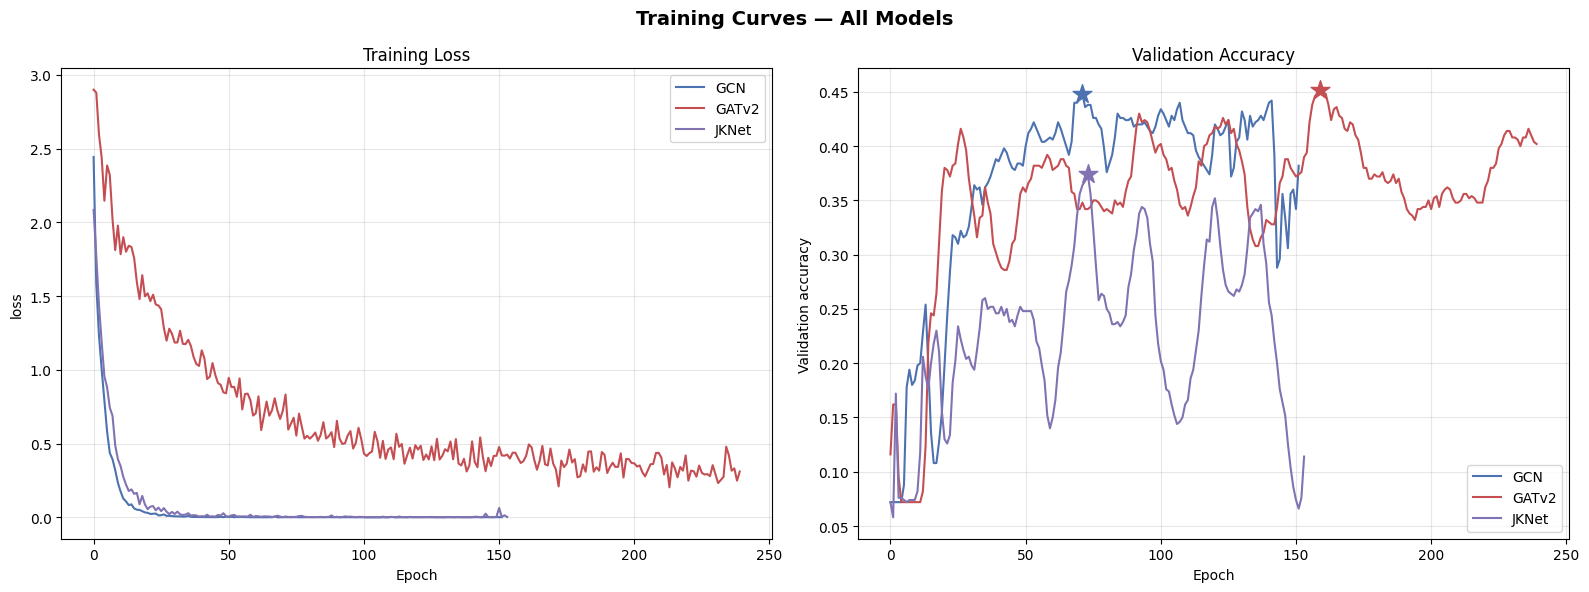

In [361]:
colors = {"GCN": "#4C72B0", "GATv2": "#C44E52","JKNet": "#8172B2"}
fig,axes = plt.subplots(1,2,figsize=(16,6))
fig.suptitle("Training Curves — All Models", fontsize=14, fontweight="bold")
for name, hist in MODEL_HISTORIES.items():
    axes[0].plot(hist["loss"],    label=name, color=colors[name], linewidth=1.5)
    axes[1].plot(hist["val_acc"], label=name, color=colors[name], linewidth=1.5)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("Training Loss")
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation accuracy")
axes[1].set_title("Validation Accuracy")
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

for name,hist in MODEL_HISTORIES.items():
  best_epoch = int(np.argmax(hist['val_acc']))
  best_val = max(hist['val_acc'])
  axes[1].scatter(best_epoch,best_val,color=colors[name],marker='*',s=200,zorder=5)


plt.tight_layout()
plt.show()

In [362]:
y_val_true = data.y[data.val_mask].numpy()

In [363]:
val_preds = {}
val_probs = {}
data = data.to(device)
print("VALIDATION METRICS -> MODEL TRAINED ON FULL FEATURE DATA")
for name, model in TRAINED_MODELS.items():
  model.eval()
  with torch.no_grad():
    logits = model(data.x,data.edge_index)
    probs = F.softmax(logits,dim=1).cpu()
    preds = logits.argmax(dim=1).cpu()
  val_probs[name] = probs
  val_preds[name] = preds[data.val_mask].numpy()
  acc = accuracy_score(y_val_true,val_preds[name])
  print(f"{name} val accuracy = {acc:.4f}")
  print(classification_report(y_val_true,val_preds[name],target_names=[f"C{i}:{CLASS_NAMES[i][:12]}" for i in range(7)],digits=3))

VALIDATION METRICS -> MODEL TRAINED ON FULL FEATURE DATA
GCN val accuracy = 0.4480
                 precision    recall  f1-score   support

  C0:Case Based      0.365     0.443     0.400        61
C1:Genetic Algo      0.556     0.417     0.476        36
C2:Neural Netwo      0.494     0.500     0.497        78
C3:Probabilisti      0.457     0.715     0.558       158
C4:Reinforcemen      0.571     0.198     0.294        81
C5:Rule Learnin      0.421     0.140     0.211        57
      C6:Theory      0.231     0.207     0.218        29

       accuracy                          0.448       500
      macro avg      0.442     0.374     0.379       500
   weighted avg      0.460     0.448     0.421       500

GATv2 val accuracy = 0.4520
                 precision    recall  f1-score   support

  C0:Case Based      0.378     0.279     0.321        61
C1:Genetic Algo      0.538     0.583     0.560        36
C2:Neural Netwo      0.561     0.474     0.514        78
C3:Probabilisti      0.533    

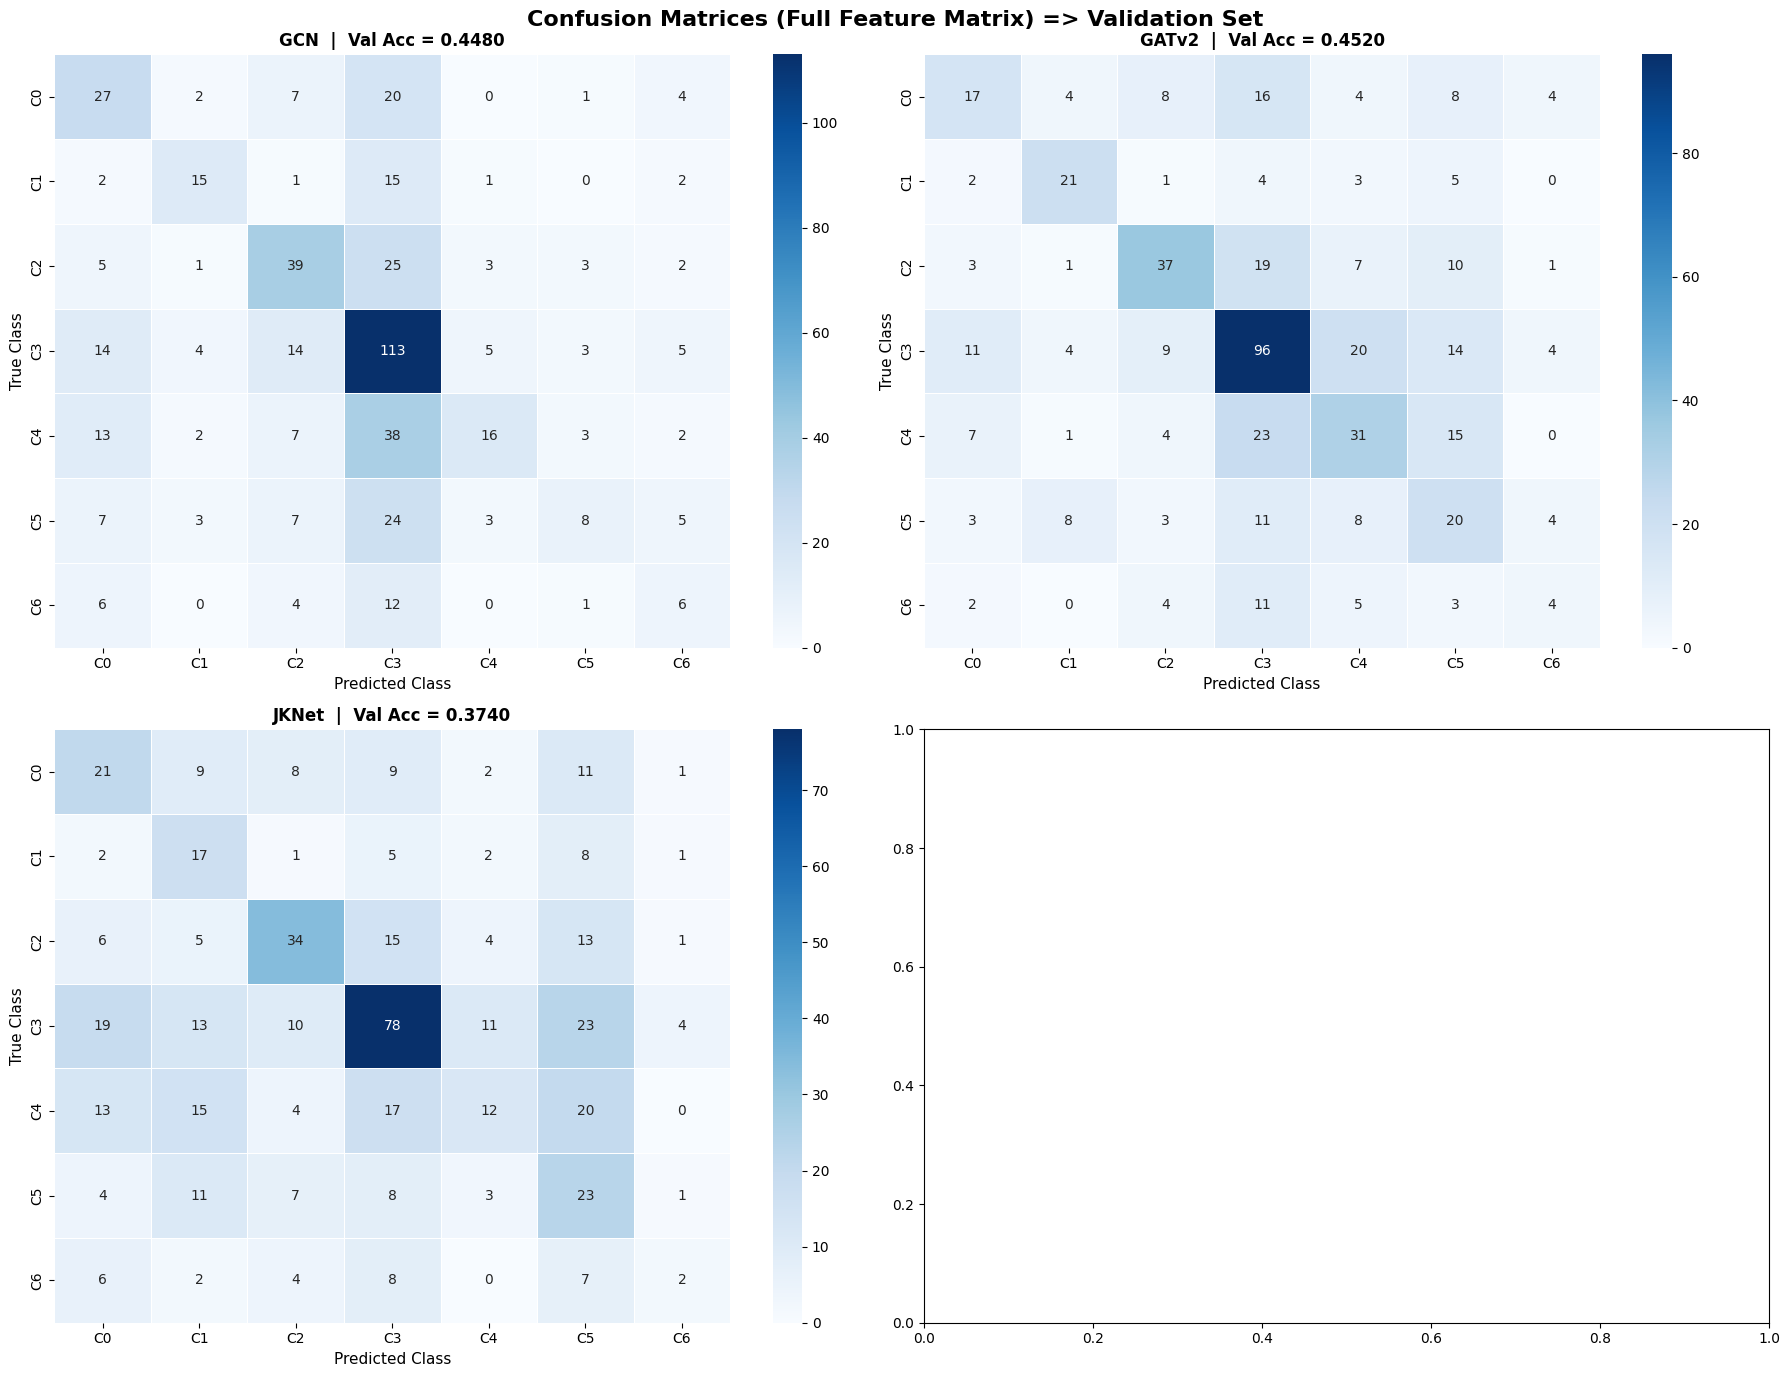

In [364]:
fig,axes = plt.subplots(2,2,figsize=(18,14))
fig.suptitle("Confusion Matrices (Full Feature Matrix) => Validation Set",fontsize=16,fontweight='bold')
axes = axes.flatten()
for idx,(name,preds) in enumerate(val_preds.items()):
  cm = confusion_matrix(y_val_true,preds)
  acc = accuracy_score(y_val_true,preds)
  short_names = [f"C{i}" for i in range(7)]
  sns.heatmap(cm,ax=axes[idx],annot=True,fmt='d',cmap="Blues",xticklabels=short_names,yticklabels=short_names,linewidth=0.5)
  axes[idx].set_xlabel("Predicted Class",fontsize=11)
  axes[idx].set_ylabel("True Class",fontsize=11)
  axes[idx].set_title(f"{name}  |  Val Acc = {acc:.4f}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


In [365]:
model_accs = {name:accuracy_score(y_val_true,pred) for name, pred in val_preds.items()}
model_accs

{'GCN': 0.448, 'GATv2': 0.452, 'JKNet': 0.374}

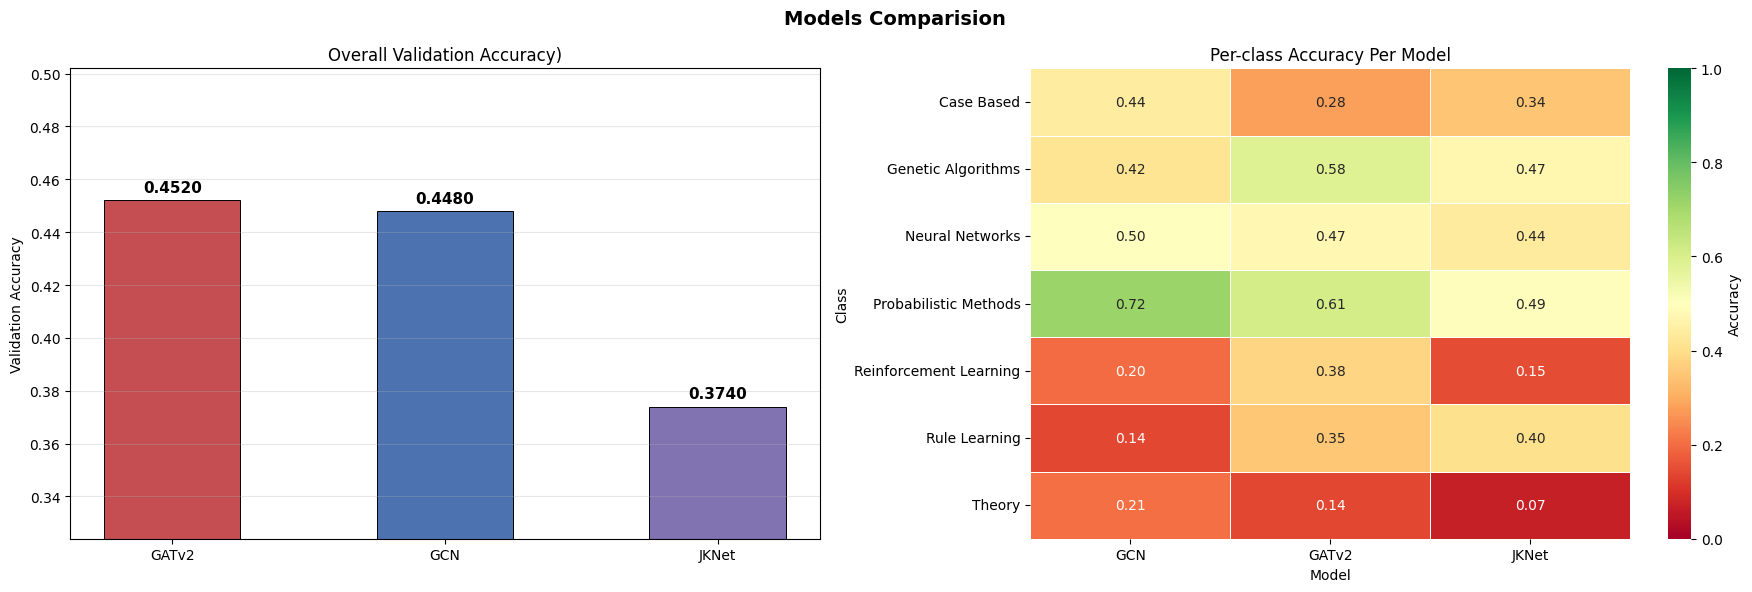

In [366]:
per_class_acc = {}
for name,preds in val_preds.items():
  cms = confusion_matrix(y_val_true,preds)
  per_class_acc[name] = cms.diagonal() / cms.sum(axis=1)
fig,axes = plt.subplots(1,2,figsize=(18,6))
fig.suptitle("Models Comparision",fontsize=14,fontweight='bold')
ax = axes[0]
names_sorted = sorted(model_accs,key=lambda n: -model_accs[n])
accs_sorted = [model_accs[n] for n in names_sorted]
bar_colors = [colors[n] for n in names_sorted]

bars = ax.bar(names_sorted,accs_sorted,color=bar_colors,edgecolor="black", linewidth=0.7, width=0.5)
ax.set_ylim(min(accs_sorted) - 0.05,min(1.0,max(accs_sorted)+0.05))
ax.set_ylabel("Validation Accuracy")
ax.set_title("Overall Validation Accuracy)")
for bar,acc in zip(bars,accs_sorted):
   ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002, f"{acc:.4f}",
            ha="center", va="bottom", fontweight="bold", fontsize=11)

ax.grid(axis='y',alpha=0.3)
ax = axes[1]
pc_df = pd.DataFrame(per_class_acc,index = [f'{CLASS_NAMES[i]}' for i in range(7)])
sns.heatmap(pc_df,ax=ax,annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=0, vmax=1, linewidths=0.5, cbar_kws={"label": "Accuracy"})
ax.set_title("Per-class Accuracy Per Model")
ax.set_xlabel("Model")
ax.set_ylabel("Class")
plt.tight_layout()
plt.show()

# Low Dimensional Data Phase

GCN


In [367]:
best_k = 128
best_data = make_denoised_data(data,best_k)

In [368]:
t0 = time.time()
gcn_model_k, gcn_acc_k, gcn_hist_k, gcn_time_k  = fit_model(GCN(in_dim=best_k,hidden_dim=256, dropout=0.5),
                                                    best_data,epochs=800, lr=0.01, weight_decay=5e-4,
                                                    patience=80,label=f'GCN_{best_k}')

Early stopping at epoch = 97
Best Val accuracy = 0.3780


In [369]:
torch.save(gcn_model_k.state_dict(), f"best_gcn_{best_k}.pt")

In [370]:
TRAINED_MODELS[f'GCN_{best_k}'] = gcn_model_k
MODEL_HISTORIES[f"GCN_{best_k}"]  = gcn_hist_k
MODEL_TIMES[f"GCN_{best_k}"]      = gcn_time_k

In [371]:
print(f"GCN  k = {best_k} | accuarcy = {gcn_acc_k:.4f}  |  time: {gcn_time_k:.0f}s")

GCN  k = 128 | accuarcy = 0.3780  |  time: 9s


GAT

In [372]:
gat_model_k, gat_acc_k, gat_hist_k, gat_time_k  = fit_model(GAT(in_dim=best_k,hidden_dim=64,out_dim=7, heads=8, dropout=0.6),
                                                    best_data,epochs=800, lr=0.005, weight_decay=5e-4,
                                                    patience=80,label=f'GAT_{best_k}')

epoch = 100 | loss = 1.3284 | val acc = 0.27000001072883606
epoch = 200 | loss = 1.2338 | val acc = 0.32600000500679016
Early stopping at epoch = 277
Best Val accuracy = 0.3340


In [373]:
torch.save(gat_model_k.state_dict(), f"best_gat_{best_k}.pt")

In [374]:
TRAINED_MODELS[f"GATv2_{best_k}"]  = gat_model_k
MODEL_HISTORIES[f"GATv2_{best_k}"] = gat_hist_k
MODEL_TIMES[f"GATv2_{best_k}"] = gat_time_k

In [375]:
print(f"GAT val accuracy:{gat_acc_k:.4f}  |  time: {gat_time_k:.0f}s")

GAT val accuracy:0.3340  |  time: 211s


JKNet

In [376]:
jk_model_k, jk_acc_k, jk_hist_k, jk_time_k  = fit_model(JKNET(in_dim=best_k,hidden_dim=128,out_dim=7,num_layers=4,dropout=0.5),
                                                best_data,epochs=800, lr=0.01, weight_decay=5e-4,
                                                patience=80,label='JKNet')

epoch = 100 | loss = 0.0035 | val acc = 0.31200000643730164
Early stopping at epoch = 110
Best Val accuracy = 0.3320


In [377]:
torch.save(jk_model_k.state_dict(), f"best_jknet_{best_k}.pt")

In [378]:
TRAINED_MODELS[f"JKNet_{best_k}"] = jk_model_k
MODEL_HISTORIES[f"JKNet_{best_k}"] = jk_hist_k
MODEL_TIMES[f"JKNet_{best_k}"] = jk_time_k

In [379]:
print(f"JKNet val accuracy:{jk_acc_k:.4f}  |  time: {jk_time_k:.0f}s")

JKNet val accuracy:0.3320  |  time: 21s


# Training Curves

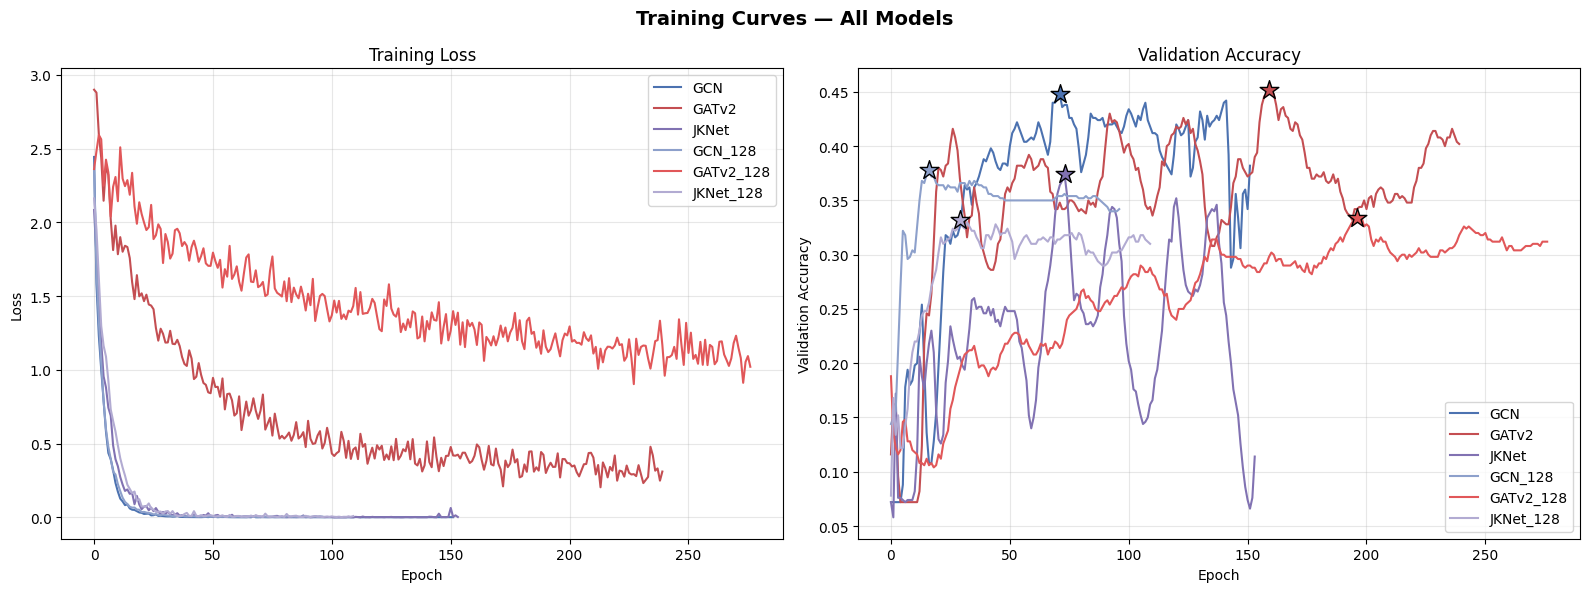

In [380]:
colors = {
    "GCN": "#4C72B0",
    "GATv2": "#C44E52",
    "JKNet": "#8172B2",
    f"GCN_{best_k}": "#8DA0CB",
    f"GATv2_{best_k}": "#E15759",
    f"JKNet_{best_k}": "#B2ABD2"
}
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Training Curves — All Models", fontsize=14, fontweight="bold")

for name, hist in MODEL_HISTORIES.items():
    axes[0].plot(hist["loss"], label=name, color=colors[name], linewidth=1.5)
    axes[1].plot(hist["val_acc"], label=name, color=colors[name], linewidth=1.5)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Accuracy")
axes[1].set_title("Validation Accuracy")
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

for name, hist in MODEL_HISTORIES.items():
    best_epoch = int(np.argmax(hist['val_acc']))
    best_val = max(hist['val_acc'])
    axes[1].scatter(best_epoch, best_val, color=colors[name], marker='*', s=200, zorder=5, edgecolors='black')

plt.tight_layout()
plt.show()

In [381]:
y_val_true = best_data.y[best_data.val_mask].numpy()

In [382]:
TRAINED_MODELS.items()

dict_items([('GCN', GCN(
  (conv1): GCNConv(1433, 256)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): GCNConv(256, 7)
)), ('GATv2', GAT(
  (conv1): GATv2Conv(1433, 64, heads=8)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): GATv2Conv(512, 7, heads=1)
)), ('JKNet', JKNET(
  (convs): ModuleList(
    (0): GCNConv(1433, 128)
    (1-3): 3 x GCNConv(128, 128)
  )
  (bns): ModuleList(
    (0-3): 4 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (jk): JumpingKnowledge(max)
  (lin): Linear(in_features=128, out_features=7, bias=True)
)), ('GCN_128', GCN(
  (conv1): GCNConv(128, 256)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): GCNConv(256, 7)
)), ('GATv2_128', GAT(
  (conv1): GATv2Conv(128, 64, heads=8)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

In [383]:
val_preds = {}
val_probs = {}
best_data = best_data.to(device)
print("VALIDATION METRICS -> MODEL TRAINED ON REDUCED FEATURE DATA")
for name,model in TRAINED_MODELS.items():
  model.eval()
  if "_128" in name:
    current_x = best_data.x
    current_edge_index = best_data.edge_index
    with torch.no_grad():
      logits = model(current_x,current_edge_index)
      probs = F.softmax(logits,dim=1).cpu()
      val_logits = logits[best_data.val_mask]
      preds = val_logits.argmax(dim=1).cpu().numpy()
    val_probs[name] = probs.numpy()
    val_preds[name] = preds
    acc = accuracy_score(y_val_true, preds)
    print(f"Model: {name}")
    print(f"Validation Acc = {acc}")
    print(classification_report(
        y_val_true,
        preds,
        target_names=[f"C{i}: {CLASS_NAMES[i][:12]}" for i in range(7)],
        digits=3
    ))

VALIDATION METRICS -> MODEL TRAINED ON REDUCED FEATURE DATA
Model: GCN_128
Validation Acc = 0.378
                  precision    recall  f1-score   support

  C0: Case Based      0.306     0.361     0.331        61
C1: Genetic Algo      0.279     0.667     0.393        36
C2: Neural Netwo      0.521     0.487     0.503        78
C3: Probabilisti      0.630     0.291     0.398       158
C4: Reinforcemen      0.467     0.346     0.397        81
C5: Rule Learnin      0.309     0.298     0.304        57
      C6: Theory      0.173     0.483     0.255        29

        accuracy                          0.378       500
       macro avg      0.383     0.419     0.369       500
    weighted avg      0.459     0.378     0.387       500

Model: GATv2_128
Validation Acc = 0.334
                  precision    recall  f1-score   support

  C0: Case Based      0.397     0.443     0.419        61
C1: Genetic Algo      0.261     0.806     0.395        36
C2: Neural Netwo      0.429     0.538     0.47

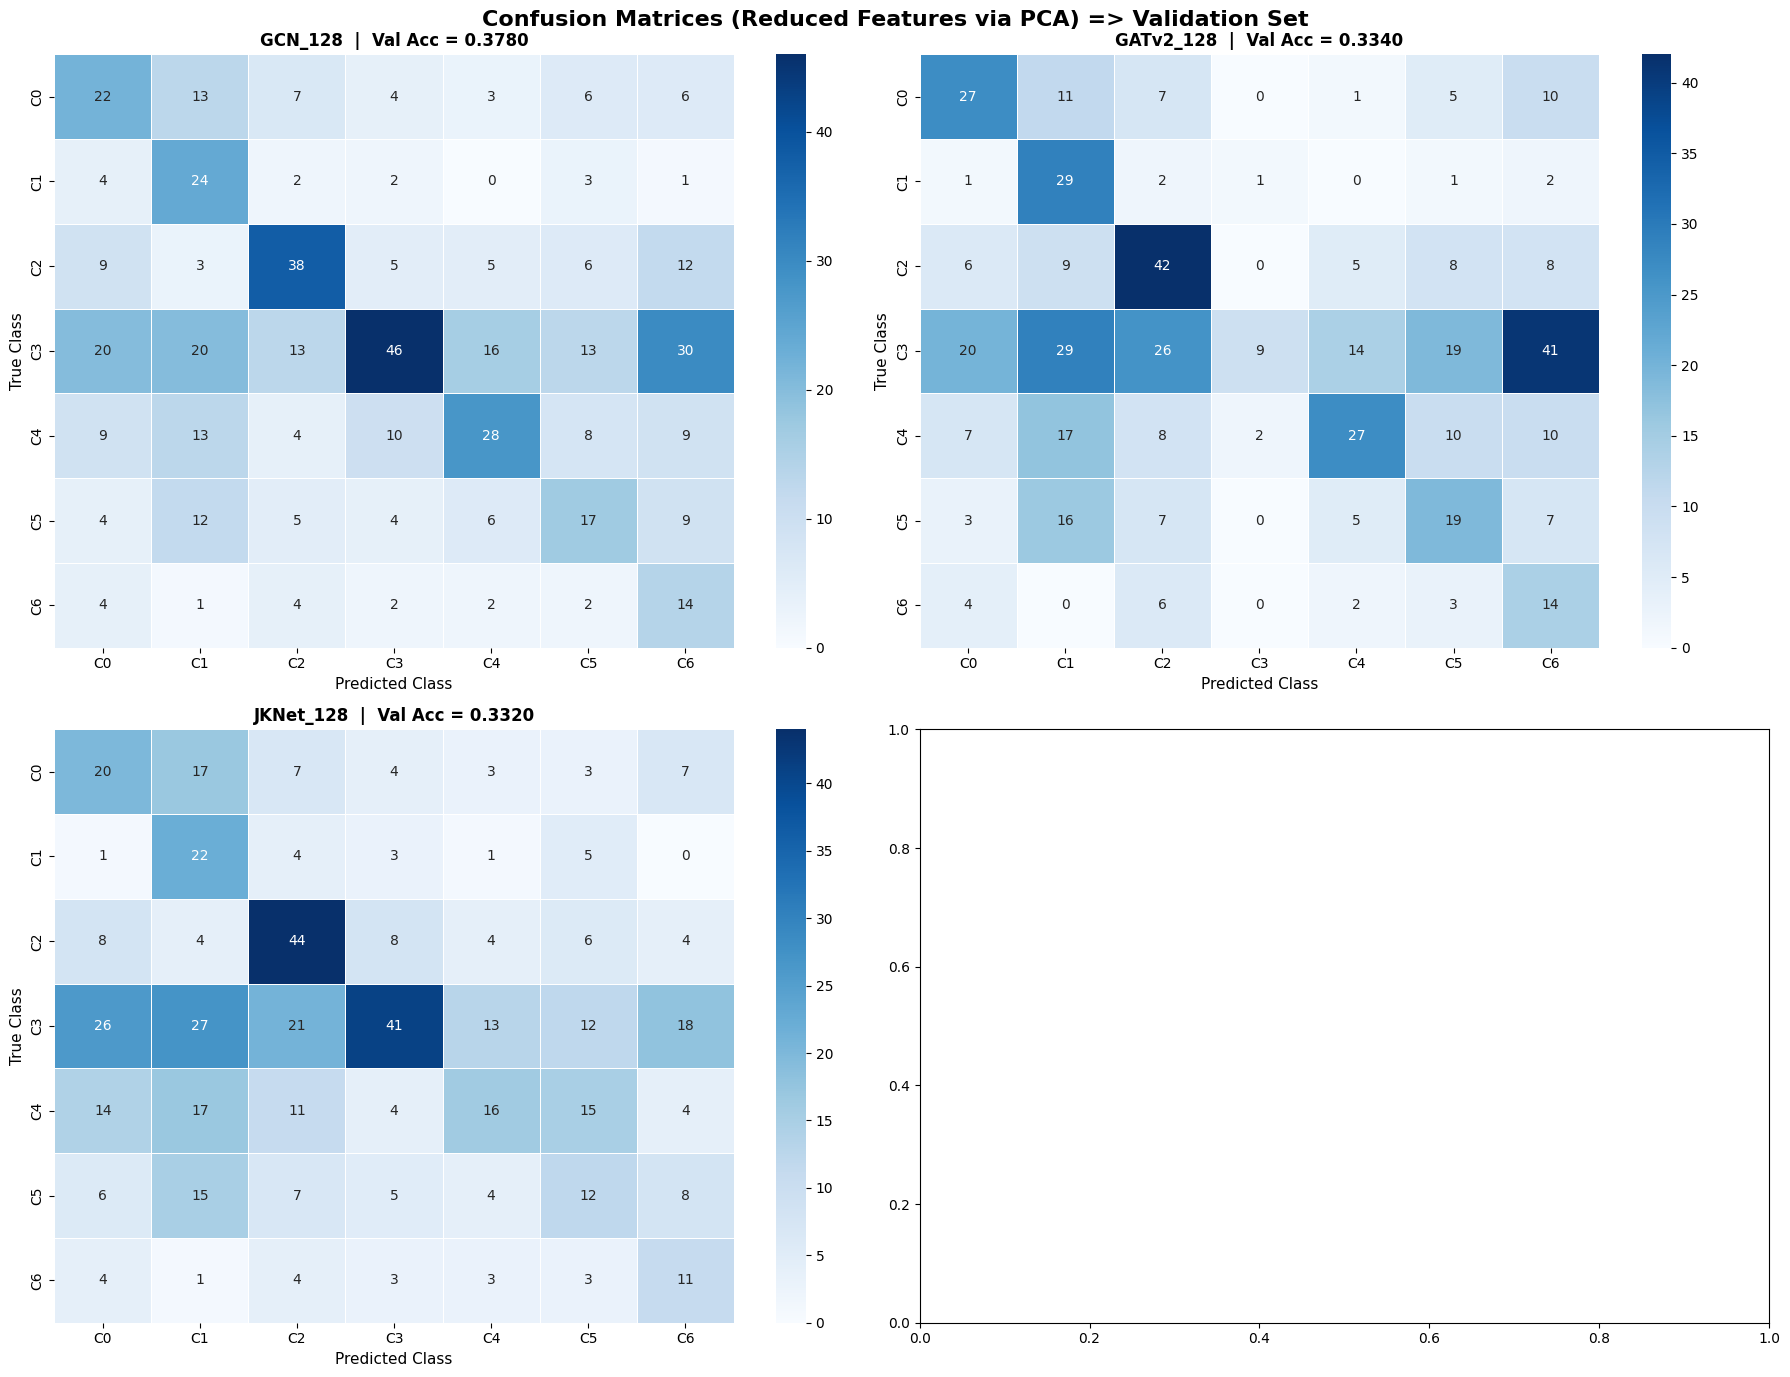

In [384]:
fig,axes = plt.subplots(2,2,figsize=(18,14))
fig.suptitle("Confusion Matrices (Reduced Features via PCA) => Validation Set",fontsize=16,fontweight='bold')
axes = axes.flatten()
for idx,(name,preds) in enumerate(val_preds.items()):
  cm = confusion_matrix(y_val_true,preds)
  acc = accuracy_score(y_val_true,preds)
  short_names = [f"C{i}" for i in range(7)]
  sns.heatmap(cm,ax=axes[idx],annot=True,fmt='d',cmap="Blues",xticklabels=short_names,yticklabels=short_names,linewidth=0.5)
  axes[idx].set_xlabel("Predicted Class",fontsize=11)
  axes[idx].set_ylabel("True Class",fontsize=11)
  axes[idx].set_title(f"{name}  |  Val Acc = {acc:.4f}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


In [385]:
model_accs_k = {name:accuracy_score(y_val_true,pred) for name, pred in val_preds.items()}
model_accs_k

{'GCN_128': 0.378, 'GATv2_128': 0.334, 'JKNet_128': 0.332}

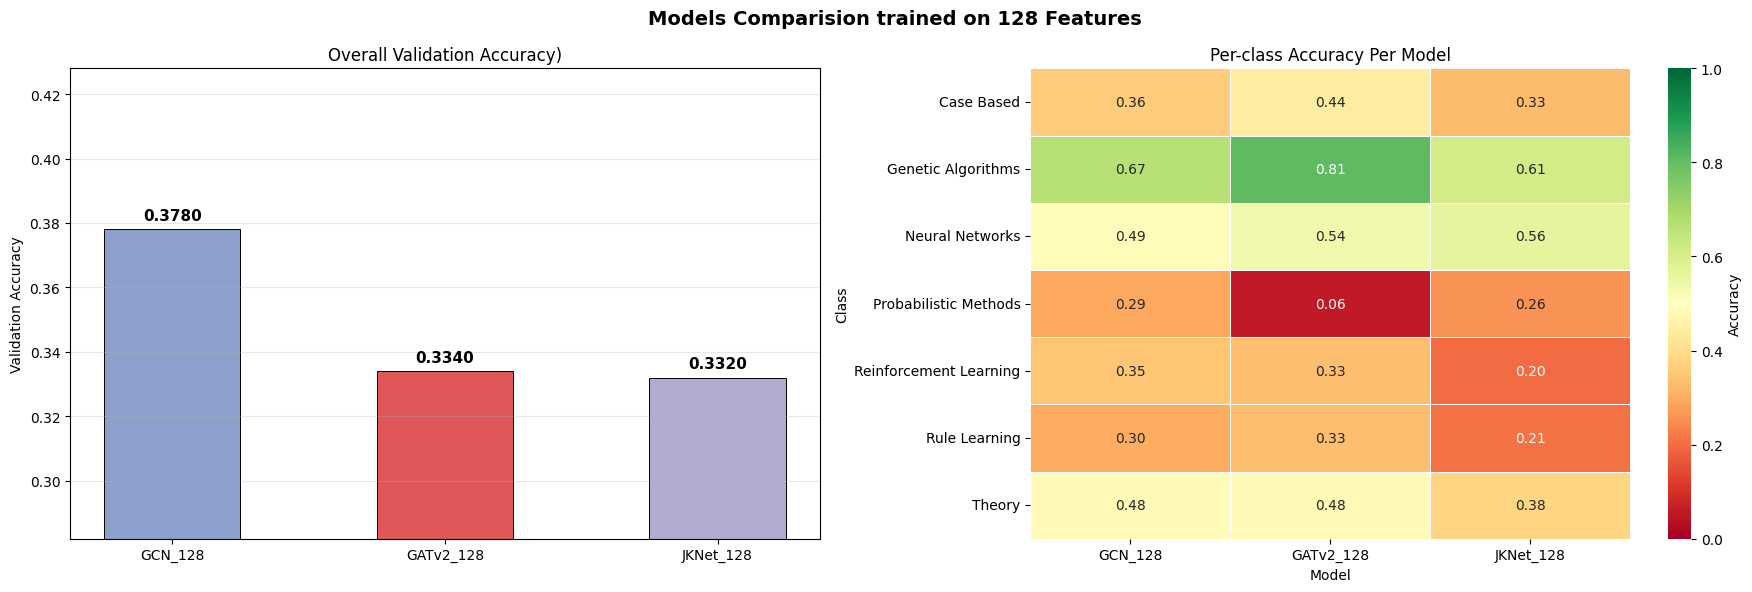

In [386]:
per_class_acc = {}
for name,preds in val_preds.items():
  cms = confusion_matrix(y_val_true,preds)
  per_class_acc[name] = cms.diagonal() / cms.sum(axis=1)
fig,axes = plt.subplots(1,2,figsize=(18,6))
fig.suptitle(f"Models Comparision trained on {best_k} Features",fontsize=14,fontweight='bold')
ax = axes[0]
names_sorted = sorted(model_accs_k,key=lambda n: -model_accs_k[n])
accs_sorted = [model_accs_k[n] for n in names_sorted]
bar_colors = [colors[n] for n in names_sorted]

bars = ax.bar(names_sorted,accs_sorted,color=bar_colors,edgecolor="black", linewidth=0.7, width=0.5)
ax.set_ylim(min(accs_sorted) - 0.05,min(1.0,max(accs_sorted)+0.05))
ax.set_ylabel("Validation Accuracy")
ax.set_title("Overall Validation Accuracy)")
for bar,acc in zip(bars,accs_sorted):
   ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002, f"{acc:.4f}",
            ha="center", va="bottom", fontweight="bold", fontsize=11)

ax.grid(axis='y',alpha=0.3)
ax = axes[1]
pc_df = pd.DataFrame(per_class_acc,index = [f'{CLASS_NAMES[i]}' for i in range(7)])
sns.heatmap(pc_df,ax=ax,annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=0, vmax=1, linewidths=0.5, cbar_kws={"label": "Accuracy"})
ax.set_title("Per-class Accuracy Per Model")
ax.set_xlabel("Model")
ax.set_ylabel("Class")
plt.tight_layout()
plt.show()

# ENSEMBLE

In [393]:
full_model_info = {
    "GCN":(TRAINED_MODELS['GCN'],0.4480),
    "GATv2":(TRAINED_MODELS['GATv2'],0.4520),
    "JKNet": (TRAINED_MODELS["JKNet"],0.3740),
}

In [395]:
accs = [a for model,a in full_model_info.values()]
weights = np.exp(accs * 10)
weights = weights / weights.sum()

In [396]:
ensemble_probs = None

In [402]:
for (name,(model,acc)),w in zip(full_model_info.items(),weights):
  model.eval()
  with torch.no_grad():
    logits = model(data.x, data.edge_index)
    probs  = F.softmax(logits, dim=1).cpu()
  ensemble_probs = probs * w if ensemble_probs is None else ensemble_probs + probs * w
  print(f"model = {name} | val acc = {acc} |  weight = {w}")

y_val_true  = data.y.cpu()[data.val_mask.cpu()].numpy()
ens_val_preds = ensemble_probs.argmax(dim=1)[data.val_mask.cpu()].numpy()
ens_acc = accuracy_score(y_val_true, ens_val_preds)

print(f"Ensemble val_accuracy = {ens_acc:.4f}")
print(f"\n Classification report of ensemble ")
print(classification_report(y_val_true,ens_val_preds,target_names=[f"C{i}:{CLASS_NAMES[i][:12]}" for i in range(7)],digits=3))

model = GCN | val acc = 0.448 |  weight = 0.03409850719324088
model = GATv2 | val acc = 0.452 |  weight = 0.034235174374152806
model = JKNet | val acc = 0.374 |  weight = 0.03166631843260632
Ensemble val_accuracy = 0.4460

 Classification report of ensemble 
                 precision    recall  f1-score   support

  C0:Case Based      0.361     0.361     0.361        61
C1:Genetic Algo      0.438     0.583     0.500        36
C2:Neural Netwo      0.507     0.474     0.490        78
C3:Probabilisti      0.515     0.639     0.571       158
C4:Reinforcemen      0.457     0.259     0.331        81
C5:Rule Learnin      0.283     0.298     0.291        57
      C6:Theory      0.250     0.138     0.178        29

       accuracy                          0.446       500
      macro avg      0.401     0.393     0.389       500
   weighted avg      0.438     0.446     0.434       500



We will choose the GATv2 because it has highest accuracy

In [404]:
gat_model_ref = TRAINED_MODELS["GATv2"]
gat_model_ref.eval()
with torch.no_grad():
  logits = gat_model_ref(data.x,)

GAT(
  (conv1): GATv2Conv(1433, 64, heads=8)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): GATv2Conv(512, 7, heads=1)
)

In [405]:
test_df

,word_0,word_1,word_2,word_3,word_4,word_5,word_6,word_7,word_8,word_9,...,word_1424,word_1425,word_1426,word_1427,word_1428,word_1429,word_1430,word_1431,word_1432,id
0,0.000000,0.838669,0.158768,0.333351,0.551831,0.106440,0.584553,0.862779,0.590877,0.000000,...,0.704692,0.000000,0.049254,0.000000,0.362039,0.363540,0.000000,0.858049,0.204279,1708
1,0.906611,0.000000,0.622145,0.122846,0.000000,0.000000,0.000000,0.418310,0.135362,0.081961,...,0.065883,0.391594,0.000000,0.000000,0.000000,1.000000,0.000000,0.527566,0.000000,1709
2,0.511272,0.000000,0.000000,0.357145,0.000000,1.000000,0.030454,0.034944,0.008704,0.692475,...,0.000000,0.000000,0.209686,0.251449,0.124740,0.000000,0.627694,0.000000,0.222555,1710
3,0.082269,0.000000,0.000000,0.000000,0.305390,0.610960,0.000000,0.000000,0.344396,0.000000,...,0.541075,0.339375,0.000000,0.346922,0.000000,0.000000,0.381799,0.580265,0.217962,1711
4,0.109147,0.000000,0.370894,0.000000,0.000000,0.000000,0.129093,0.000000,0.159227,0.000000,...,0.149388,0.000000,0.000000,0.220777,0.332561,0.000000,0.243883,0.456263,0.000000,1712
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.000000,0.575322,0.000000,0.000000,0.000000,1.000000,0.412258,0.000000,0.021609,0.000000,...,0.000000,0.303646,0.000000,0.093272,0.740840,0.428185,0.000000,0.000000,0.000000,2703
996,0.441452,0.467554,0.751437,0.436792,0.000000,0.753938,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.127731,0.140611,0.000000,0.288298,0.316205,0.000000,0.359294,0.000000,2704
997,0.000000,0.000000,0.288341,0.467203,0.324445,0.000000,0.000000,0.414500,0.512344,0.170177,...,0.103881,0.521966,0.000000,0.000000,0.036674,0.564865,0.000000,0.309021,0.480791,2705
998,0.478369,0.173873,0.000000,0.000000,0.000000,0.000000,0.109117,0.074769,0.000000,0.133593,...,0.000000,0.000000,0.274917,0.409997,0.025766,0.000000,0.000000,0.000658,0.000000,2706


In [387]:
TOTAL_TIME = time.time() - START_TIME
print(f"TOTAL_TIME = {TOTAL_TIME:.0f}s ")

TOTAL_TIME = 667s 


In [388]:
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')f
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')
print('faran')

SyntaxError: invalid syntax (1397356055.py, line 27)

In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 74.2 MB/s eta 0:00:00


In [ ]:
import copy
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import scipy.sparse as sp
import matplotlib.gridspec as gs
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATv2Conv, APPNP, JumpingKnowledge, LabelPropagation
from torch_geometric.utils import from_scipy_sparse_matrix, to_undirected, remove_self_loops
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from collections import Counter
import platform
import time

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [ ]:
SEED=25
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
print(f"OS = {platform.system()} {platform.release()}")
print(f"processor = {platform.system()}")

OS = Linux 6.6.113+
processor = Linux


In [ ]:
print(f"Pytorch Version = {torch.__version__}")

Pytorch Version = 2.10.0+cpu


In [ ]:
START_TIME = time.time()

# Loading Data and Validation

In [ ]:
train_val_df = pd.read_csv('train_val_labeled.csv')
test_df = pd.read_csv('test_features_only.csv')
adj_df = pd.read_csv('adjacency_matrix.csv')

In [ ]:
print(f"Train Val shape  = {train_val_df.shape}")
print(f"Test shape = {test_df.shape}")
print(f"Adj shape = {adj_df.shape}")

Train Val shape  = (640, 1435)
Test shape = (1000, 1434)
Adj shape = (2707, 2708)


In [ ]:
train_val_df.head()

,word_0,word_1,word_2,word_3,word_4,word_5,word_6,word_7,word_8,word_9,...,word_1425,word_1426,word_1427,word_1428,word_1429,word_1430,word_1431,word_1432,target,id
0,0.000000,0.254512,0.000000,0.000000,0.396139,0.189993,0.000000,0.000000,0.000000,0.062381,...,0.619050,0.000000,0.266029,0.518465,0.000000,1.000000,0.954291,0.671058,3,0
1,0.000000,0.412502,0.000000,0.000000,0.000000,0.078024,0.073060,0.359106,0.000000,0.365384,...,0.000000,0.671789,0.647814,0.000000,0.000000,0.195134,0.252293,0.000000,4,1
2,0.038983,0.128888,0.266918,0.671799,0.432882,0.255227,0.000000,0.000000,0.352532,0.065281,...,0.596002,0.000000,0.000000,0.000000,0.000000,0.090133,0.000000,0.000000,4,2
3,0.000000,0.000000,0.454025,0.000000,0.000000,0.346009,0.093135,0.507108,0.502581,0.000000,...,0.333688,0.000000,0.484122,0.012767,0.484841,0.247734,0.787112,0.370596,0,3
4,0.236430,0.000000,0.468288,0.565917,0.000000,0.000000,0.619783,0.000000,0.000000,0.010897,...,0.012419,0.000000,0.289624,0.267483,0.034960,0.147601,0.000000,0.000000,3,4


In [ ]:
feat_cols = [c for c in train_val_df.columns if c.startswith('word_')]

In [ ]:
labeled_ids = train_val_df['id'].values
labeled_feats  = train_val_df[feat_cols].values.astype(np.float32)
labeled_labels = train_val_df['target'].values.astype(np.int64)

In [ ]:
NUM_CLASSES = len(np.unique(labeled_labels))

In [ ]:
test_df.head(2)

,word_0,word_1,word_2,word_3,word_4,word_5,word_6,word_7,word_8,word_9,...,word_1424,word_1425,word_1426,word_1427,word_1428,word_1429,word_1430,word_1431,word_1432,id
0,0.000000,0.838669,0.158768,0.333351,0.551831,0.10644,0.584553,0.862779,0.590877,0.000000,...,0.704692,0.000000,0.049254,0.0,0.362039,0.36354,0.0,0.858049,0.204279,1708
1,0.906611,0.000000,0.622145,0.122846,0.000000,0.00000,0.000000,0.418310,0.135362,0.081961,...,0.065883,0.391594,0.000000,0.0,0.000000,1.00000,0.0,0.527566,0.000000,1709


In [ ]:
test_ids = test_df['id'].values
test_feats = test_df[feat_cols].values.astype(np.float32)

In [ ]:
train_ids = labeled_ids[:140]
val_ids = labeled_ids[140:]

In [ ]:
print(f"Labeled node IDs = {labeled_ids.min()}  - {labeled_ids.max()}")
print(f"Labeled node IDs = {test_ids.min()}  - {test_ids.max()}")

Labeled node IDs = 0  - 639
Labeled node IDs = 1708  - 2707


In [ ]:
np.bincount(labeled_labels[:140]).tolist()

[20, 20, 20, 20, 20, 20, 20]

In [ ]:
print(f"train split size = {len(train_ids)} , {np.bincount(labeled_labels[:140]).tolist()} split per class")
print(f'val split size = {len(val_ids)}')
print(f'test split size = {len(test_ids)}')

train split size = 140 , [20, 20, 20, 20, 20, 20, 20] split per class
val split size = 500
test split size = 1000


In [ ]:
NUM_NODES = adj_df.shape[1]

In [ ]:
full_features = np.zeros((NUM_NODES,len(feat_cols)),dtype=np.float32)
full_labels= np.full(NUM_NODES,-1,dtype=np.int64)
full_features.shape, full_labels.shape

((2708, 1433), (2708,))

In [ ]:
for i, nid in enumerate(labeled_ids):
  full_features[nid] = labeled_feats[i]
  full_labels[nid] = labeled_labels[i]

In [ ]:
for i,nid in enumerate(test_ids):
  full_features[nid] = test_feats[i]

In [ ]:
all_feat_ids = np.concatenate([labeled_ids,test_ids])
g_ids = sorted(set(range(NUM_NODES)) - set(all_feat_ids))

In [ ]:
print(f"Full Feature matrix shape = {full_features.shape}")
print(f"Nodes with features = {len(all_feat_ids)}")
print(f'Nodes without features = {len(g_ids)}')

Full Feature matrix shape = (2708, 1433)
Nodes with features = 1640
Nodes without features = 1068


In [ ]:
adj_raw = adj_df.values.astype(np.float32)
f"Adjacency matrix shape = {adj_raw.shape}"

'Adjacency matrix shape = (2707, 2708)'

In [ ]:
adj_full = np.zeros((NUM_NODES,NUM_NODES),dtype=np.float32)
adj_full[:adj_raw.shape[0],:adj_raw.shape[1]] = adj_raw

In [ ]:
adj_sym = np.maximum(adj_full,adj_full.T)
np.fill_diagonal(adj_sym,0)

In [ ]:
print(f"Fixed adjancecy matrix shape = {adj_sym.shape}")
print(f"Total edges undirected = {adj_sym.sum() / 2}")

Fixed adjancecy matrix shape = (2708, 2708)
Total edges undirected = 10367.0


# EDA

In [ ]:
G_nx = nx.from_numpy_array(adj_sym)
degrees = [d  for _,d in G_nx.degree()]
comps = sorted(nx.connected_components(G_nx),key=len,reverse=True)
cc_sizes = [len(c) for c in comps]

In [ ]:
print(f"Graph Topology Summary:")
print(f"{'Num nodes'} =  {G_nx.number_of_nodes()}")
print(f"{'Num edges'} = {G_nx.number_of_edges()}")
print(f"{'Self loops'} = {nx.number_of_selfloops(G_nx)}")
print(f"{'Is connected'} = {nx.is_connected(G_nx)}")
print(f"{'Num connected components'} = {len(comps)}")
print(f"{'Largest component size'} = {cc_sizes[0]}")
print(f"{'Min degree'} = {min(degrees)}")
print(f"{'Max degree'} = {max(degrees)}")
print(f"{'Mean degree'} = {np.mean(degrees):.2f}")
print(f"{'Median degree'} = {np.median(degrees):.0f}")

Graph Topology Summary:
Num nodes =  2708
Num edges = 10367
Self loops = 0
Is connected = False
Num connected components = 7
Largest component size = 2702
Min degree = 0
Max degree = 173
Mean degree = 7.66
Median degree = 6


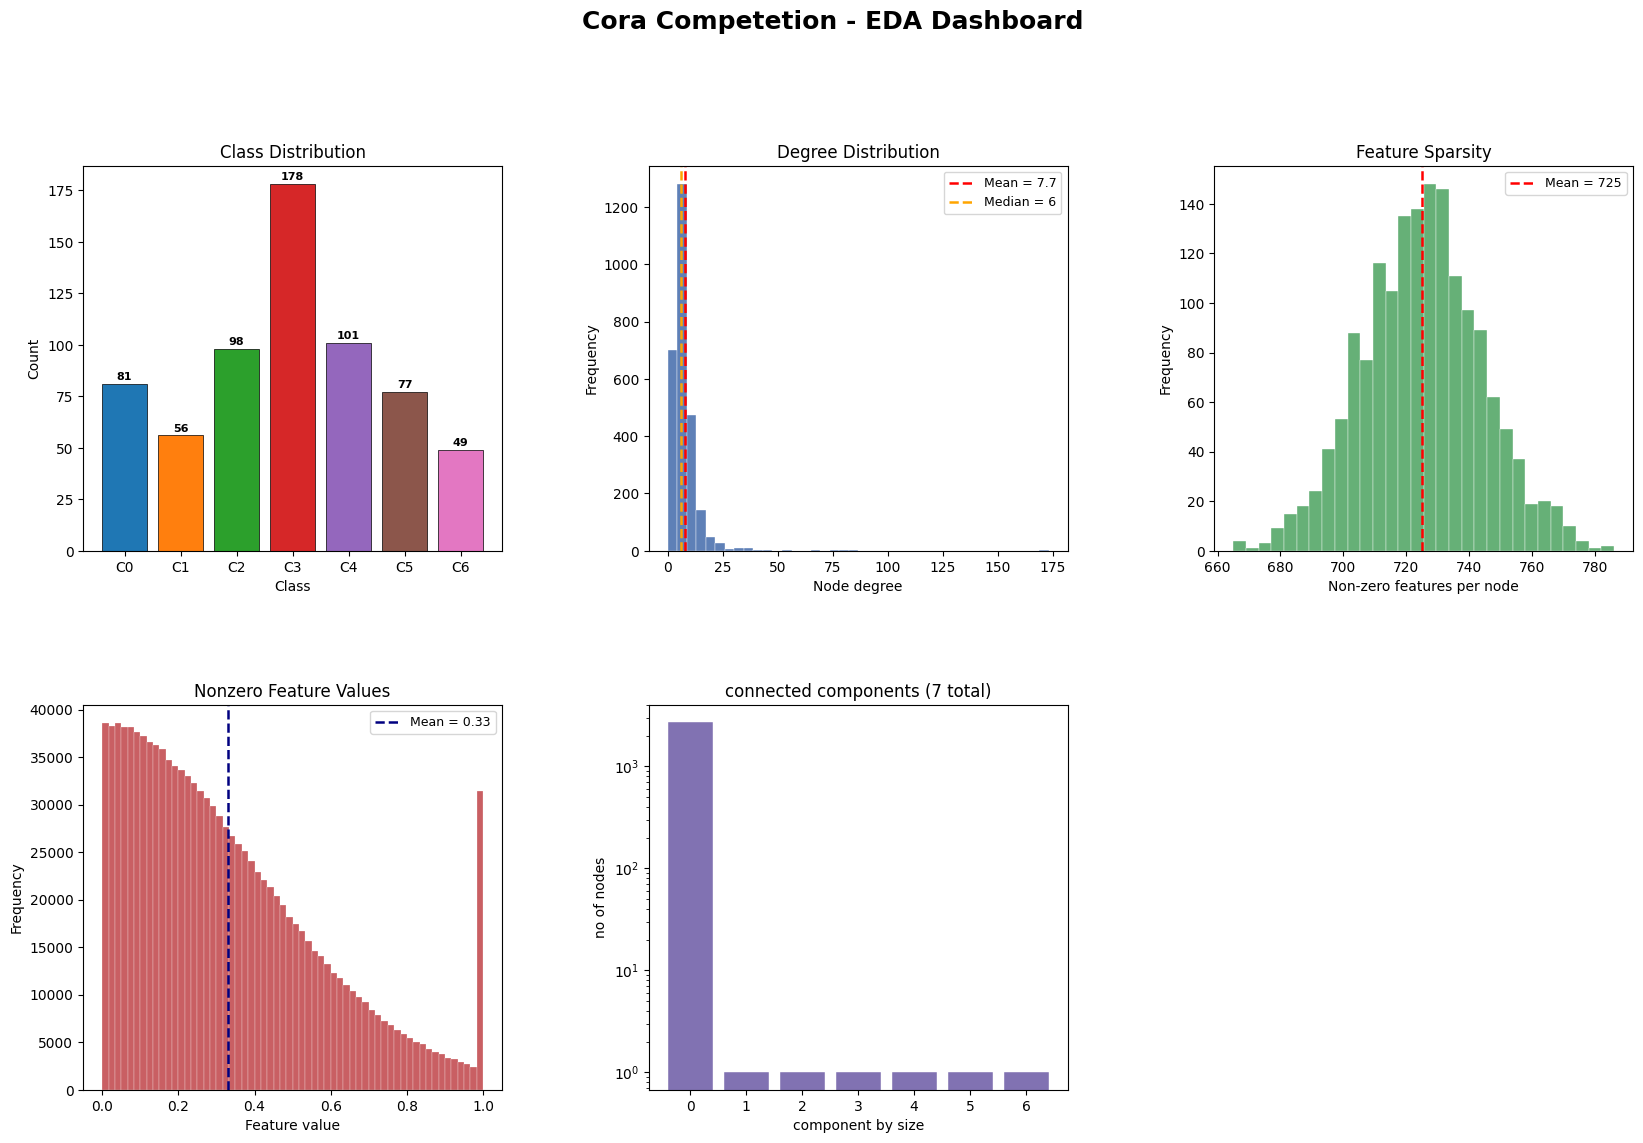

In [ ]:
fig = plt.figure(figsize=(20,12))
fig.suptitle("Cora Competetion - EDA Dashboard",fontsize=18, fontweight='bold',y=1.01)
g = gs.GridSpec(2,3,figure=fig,hspace=0.4,wspace=0.35)
palette = sns.color_palette('tab10',NUM_CLASSES)
class_counts = pd.Series(labeled_labels).value_counts().sort_index()
ax1 = fig.add_subplot(g[0, 0])
bars = ax1.bar(class_counts.index, class_counts.values,
               color=palette, edgecolor="black", linewidth=0.5)
ax1.set_xticks(range(7))
ax1.set_xticklabels([f"C{i}" for i in range(7)])
ax1.set_xlabel("Class")
ax1.set_ylabel("Count")
ax1.set_title("Class Distribution")
for bar, cnt in zip(bars, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1, str(cnt),
             ha="center", va="bottom", fontsize=8, fontweight="bold")


ax2 = fig.add_subplot(g[0, 1])
ax2.hist(degrees, bins=40, color="#4C72B0", edgecolor="white",
         linewidth=0.3, alpha=0.9)
ax2.axvline(np.mean(degrees),   color="red",    linestyle="--",
            lw=1.8, label=f"Mean = {np.mean(degrees):.1f}")
ax2.axvline(np.median(degrees), color="orange", linestyle="--",
            lw=1.8, label=f"Median = {np.median(degrees):.0f}")
ax2.set_xlabel("Node degree")
ax2.set_ylabel("Frequency")
ax2.set_title("Degree Distribution")
ax2.legend(fontsize=9)

ax3 = fig.add_subplot(g[0, 2])
nonzero_counts = np.count_nonzero(full_features[all_feat_ids], axis=1)
ax3.hist(nonzero_counts, bins=30, color="#55A868", edgecolor="white",
         linewidth=0.3, alpha=0.9)
ax3.axvline(nonzero_counts.mean(), color="red", linestyle="--",
            lw=1.8, label=f"Mean = {nonzero_counts.mean():.0f}")
ax3.set_xlabel("Non-zero features per node")
ax3.set_ylabel("Frequency")
ax3.set_title("Feature Sparsity")
ax3.legend(fontsize=9)

ax4 = fig.add_subplot(g[1, 0])
nonzero_vals = full_features[all_feat_ids].flatten()
nonzero_vals = nonzero_vals[nonzero_vals > 0]
ax4.hist(nonzero_vals, bins=60, color="#C44E52", edgecolor="white",
         linewidth=0.2, alpha=0.9)
ax4.set_xlabel("Feature value")
ax4.set_ylabel("Frequency")
ax4.set_title("Nonzero Feature Values")
ax4.axvline(nonzero_vals.mean(), color="navy", linestyle="--",
            lw=1.8, label=f"Mean = {nonzero_vals.mean():.2f}")
ax4.legend(fontsize=9)
ax5 = fig.add_subplot(g[1, 1])
ax5.bar(range(min(20, len(cc_sizes))), cc_sizes[:20],
        color="#8172B2", edgecolor="white", linewidth=0.3)
ax5.set_xlabel("component by size")
ax5.set_ylabel("no of nodes")
ax5.set_title(f"connected components ({len(comps)} total)")
ax5.set_yscale("log")
plt.show()

In [ ]:
class_counts

,count
0,81
1,56
2,98
3,178
4,101
5,77
6,49


In [ ]:
tsne = TSNE(n_components=2,perplexity=30,n_iter=1000, random_state=SEED,verbose=0)
X_tsne = tsne.fit_transform(labeled_feats)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [ ]:
CLASS_NAMES = [
    "Case Based",
    "Genetic Algorithms",
    "Neural Networks",
    "Probabilistic Methods",
    "Reinforcement Learning",
    "Rule Learning",
    "Theory",
]


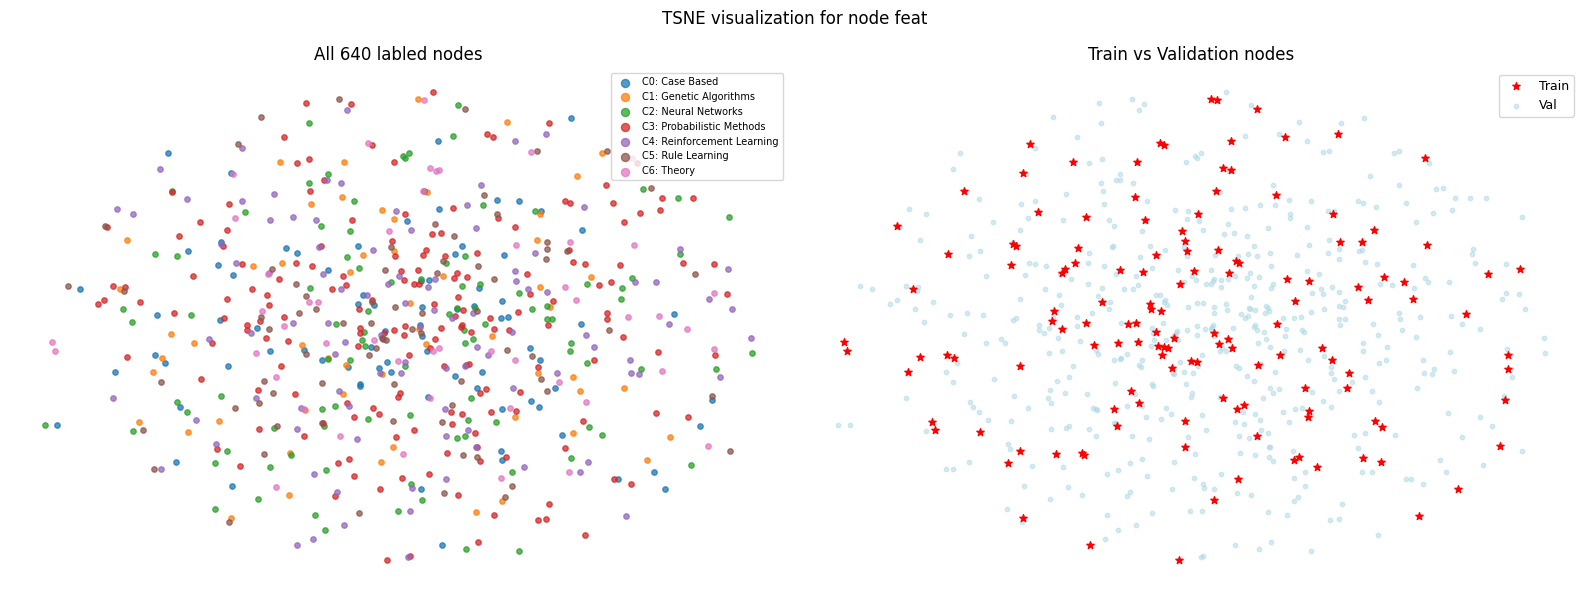

In [ ]:
fig,axes = plt.subplots(1,2,figsize=(16,6))
fig.suptitle('TSNE visualization for node feat')
ax = axes[0]
for cls in range(NUM_CLASSES):
  mask = labeled_labels == cls
  ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],c=[palette[cls]], label=f"C{cls}: {CLASS_NAMES[cls]}",s=15, alpha=0.75)
ax.set_title("All 640 labled nodes")
ax.legend(fontsize=7,markerscale=1.5,loc='upper right')
ax.axis('off')

ax = axes[1]
ax.scatter(X_tsne[:140,0],X_tsne[:140,1],c='red',s=30,alpha=1.0,label="Train",marker="*",zorder=3)
ax.scatter(X_tsne[140:,0],X_tsne[140:,1],c='lightblue',s=10, alpha=0.5, label="Val")
ax.set_title("Train vs Validation nodes")
ax.legend(fontsize=9)
ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
class_feat_means = []
for cls in range(NUM_CLASSES):
  mask = labeled_labels == cls
  class_feat_means.append(labeled_feats[mask].mean(axis=0))
class_feat_means = np.array(class_feat_means)

In [ ]:
feat_disc = class_feat_means.var(axis=0)
top_feat_indices = np.argsort(feat_disc)[::-1][:30]

In [ ]:
top_feat_indices

array([1263,  495,  581,  507, 1209,  750,    4,  774,   19, 1132,  814,
       1005,   99,  729, 1170, 1149,  758,  544,  725, 1177,  874, 1199,
       1259, 1203, 1151,  485,  299, 1265,  978,  205])

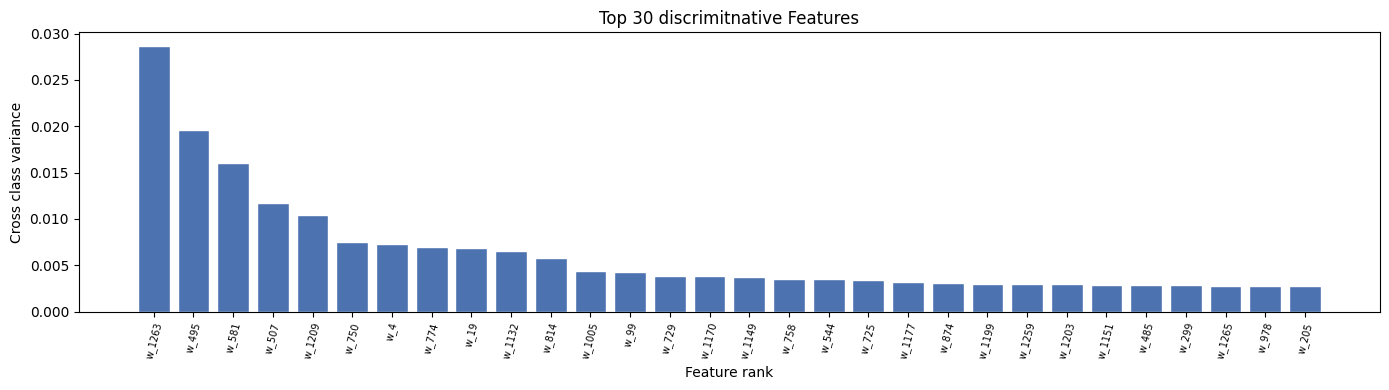

In [ ]:
fig,ax = plt.subplots(figsize=(14,4))
ax.bar(range(30), feat_disc[top_feat_indices], color='#4C72B0', edgecolor='white')
ax.set_xlabel("Feature rank")
ax.set_ylabel('Cross class variance')
ax.set_title('Top 30 discrimitnative Features')
ax.set_xticks(range(30))
ax.set_xticklabels([f'w_{i}' for i in top_feat_indices],rotation=75,fontsize=7)
plt.tight_layout()
plt.show()

# Graph Construction

In [ ]:
adj_sparse = sp.coo_matrix(adj_sym)
edge_index,_ = from_scipy_sparse_matrix(adj_sparse)
edge_index = to_undirected(edge_index, num_nodes=NUM_NODES)
edge_index,_= remove_self_loops(edge_index)

In [ ]:
train_mask = torch.zeros(NUM_NODES, dtype=torch.bool)
val_mask = torch.zeros(NUM_NODES, dtype=torch.bool)
test_mask = torch.zeros(NUM_NODES, dtype=torch.bool)

In [ ]:
train_mask[torch.LongTensor(train_ids)] = True
val_mask[torch.LongTensor(val_ids)] = True
test_mask[torch.LongTensor(test_ids)] = True

In [ ]:
data = Data(x=torch.FloatTensor(full_features),y=torch.LongTensor(full_labels),edge_index=edge_index,train_mask=train_mask,val_mask=val_mask,test_mask=test_mask)

In [ ]:
data.test_ids = torch.LongTensor(test_ids)

In [ ]:
print(f'data object = {data}')
print(f'Edge Index shape = {edge_index.shape} -> {edge_index.shape[1]} directed edges')
print(f'Train -> {train_mask.sum()} | Val -> {val_mask.sum()} | Test -> {test_mask.sum()}')

data object = Data(x=[2708, 1433], edge_index=[2, 20734], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708], test_ids=[1000])
Edge Index shape = torch.Size([2, 20734]) -> 20734 directed edges
Train -> 140 | Val -> 500 | Test -> 1000


In [ ]:
all_labeled_y = data.y[train_mask | val_mask]
counts = torch.bincount(all_labeled_y, minlength=NUM_CLASSES).float()
class_weights = counts.sum() / (NUM_CLASSES * counts)

In [ ]:
data.class_weights = class_weights

In [ ]:
for i in range(NUM_CLASSES):
  print(f"Class {i} -> counts = {int(counts[i])} weight = {class_weights[i]:.3f} ")

Class 0 -> counts = 81 weight = 1.129 
Class 1 -> counts = 56 weight = 1.633 
Class 2 -> counts = 98 weight = 0.933 
Class 3 -> counts = 178 weight = 0.514 
Class 4 -> counts = 101 weight = 0.905 
Class 5 -> counts = 77 weight = 1.187 
Class 6 -> counts = 49 weight = 1.866 


# Feature Engineering

In [ ]:
scaler_ref = StandardScaler()
X_ref = scaler_ref.fit_transform(full_features)
pca_ref = PCA(n_components=512,random_state=SEED)
pca_ref.fit(X_ref)
cumvar = np.cumsum(pca_ref.explained_variance_ratio_)

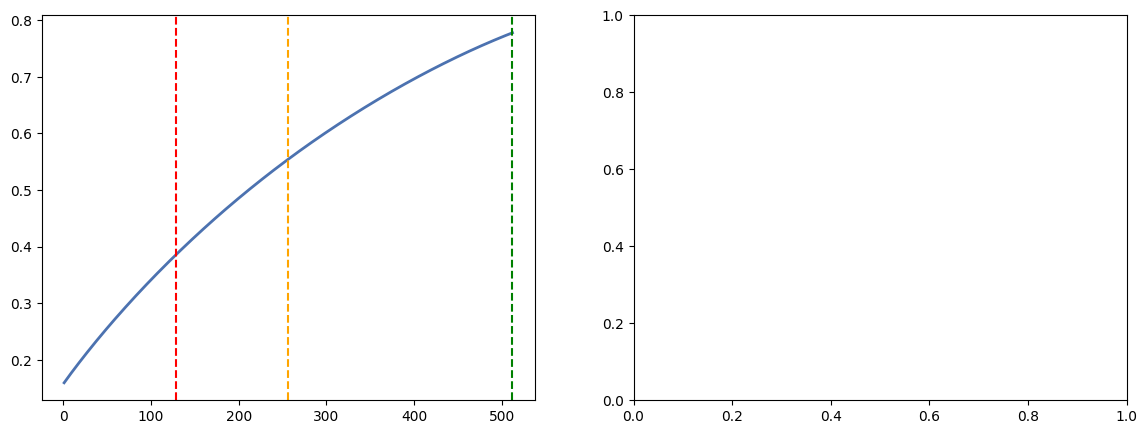

In [ ]:
fig,axes =  plt.subplots(1,2,figsize=(14,5))
ax = axes[0]
ax.plot(range(1,513),cumvar,color='#4C72B0',linewidth=2)
for k,col in [(128,'red'), (256,'orange'),(512,'green')]:
  ax.axvline(k,color=col,linestyle="--",linewidth=1.5,label=f"k={k}:{cumvar[k-1]:.1%}")

In [ ]:
def make_denoised_data(base_data,n_components):
  X = base_data.x.numpy()
  scaler = StandardScaler()
  X_scaled = scaler.fit_transform(X)
  pca = PCA(n_components=n_components,random_state=SEED)
  X_low = pca.fit_transform(X_scaled).astype(np.float32)
  new_data = copy.copy(base_data)
  new_data.x = torch.FloatTensor(X_low)
  return new_data

# MODELS

In [ ]:
class GCN(nn.Module):
  def __init__(self,in_dim,hidden_dim,out_dim=7,dropout=0.5):
    super().__init__()
    self.dropout = dropout
    self.conv1 = GCNConv(in_dim,hidden_dim,cached=True,normalize=True)
    self.bn1 = nn.BatchNorm1d(hidden_dim)
    self.conv2 = GCNConv(hidden_dim,out_dim,cached=True,normalize=True)
  def forward(self,x,edge_index):
    x = self.conv1(x,edge_index)
    x = self.bn1(x)
    x = F.relu(x)
    x = F.dropout(x,p=self.dropout,training=self.training)
    x = self.conv2(x,edge_index)
    return x
  def reset_parameters(self):
    self.conv1.reset_parameters()
    self.conv2.reset_parameters()
    self.bn1.reset_paramteres()

In [ ]:
def train(model,data,optimizer,class_weights):
  model.train()
  optimizer.zero_grad()
  logits = model(data.x,data.edge_index)
  loss = F.cross_entropy(
      logits[data.train_mask],
      data.y[data.train_mask],
      weight = class_weights
  )
  loss.backward()
  optimizer.step()
  return loss.item()

In [ ]:
@torch.no_grad()
def validate(model,data):
  model.eval()
  logits = model(data.x,data.edge_index)
  probs = F.softmax(logits,dim=1)
  preds = logits.argmax(dim=1)
  val_acc = (preds[data.val_mask] == data.y[data.val_mask]).float().mean().item()
  return val_acc, probs.cpu()


In [ ]:
def fit_model(model,data,epochs=500,lr=0.005,weight_decay=5e-4, patience=80, label="model",v=True):
  data = data.to(device)
  model = model.to(device)
  cw = data.class_weights.to(device)
  optimizer = torch.optim.Adam(model.parameters(),lr=lr,weight_decay=weight_decay)
  scheduler = CosineAnnealingLR(optimizer,T_max=epochs,eta_min=1e-5)
  best_val_acc = 0.0
  best_state = None
  patience_ctr = 0
  history = {"loss":[],"val_acc":[]}
  t_start = time.time()
  for epoch in range(1,epochs+1):
    loss = train(model,data,optimizer,cw)
    val_acc,_ = validate(model,data)
    scheduler.step()
    history['loss'].append(loss)
    history['val_acc'].append(val_acc)
    if val_acc > best_val_acc:
      best_val_acc = val_acc
      best_state = copy.deepcopy(model.state_dict())
      patience_ctr = 0

    else:
      patience_ctr += 1

    if patience_ctr >= patience:
      print(f"Early stopping at epoch = {epoch}")
      print(f'Best Val accuracy = {best_val_acc:.4f}')
      break

    if epoch % 100 == 0:
      print(f"epoch = {epoch} | loss = {loss:.4f} | val acc = {val_acc}")


  elapsed = time.time() - t_start
  model.load_state_dict(best_state)
  model.eval()
  return model, best_val_acc, history, elapsed

In [ ]:
HP_RESULTS = []
hp_run_count = 0
for n_comp in [128, 256, 512]:
  hp_run_count += 1
  probe_data = make_denoised_data(data,n_comp)
  probe_model = GCN(in_dim=n_comp,hidden_dim=256,dropout=0.7)
  t0 = time.time()
  probe_model,acc,history,_ = fit_model(probe_model,probe_data,epochs=400,lr=0.01,patience=40,label=f"GCN-probe-k{n_comp}")
  elapsed = time.time() - t0
  logs = {
      "run":hp_run_count,
      "pca_k":n_comp,
      'model':"GCN",
      'val_acc':round(acc,5),
      "time_sec":round(elapsed,1)
  }
  HP_RESULTS.append(logs)
  print(f'PCA {n_comp} -> val_acc = {acc:.4f} time taken = {elapsed:.0f}s')


Early stopping at epoch = 75
Best Val accuracy = 0.3780
PCA 128 -> val_acc = 0.3780 time taken = 6s
Early stopping at epoch = 56
Best Val accuracy = 0.4200
PCA 256 -> val_acc = 0.4200 time taken = 6s
Early stopping at epoch = 62
Best Val accuracy = 0.4060
PCA 512 -> val_acc = 0.4060 time taken = 7s


In [ ]:
HP_RESULTS

[{'run': 1, 'pca_k': 128, 'model': 'GCN', 'val_acc': 0.378, 'time_sec': 6.2},
 {'run': 2, 'pca_k': 256, 'model': 'GCN', 'val_acc': 0.42, 'time_sec': 5.8},
 {'run': 3, 'pca_k': 512, 'model': 'GCN', 'val_acc': 0.406, 'time_sec': 6.5}]

In [ ]:
best_k = 128
best_data = make_denoised_data(data,best_k)

In [ ]:
class GAT(nn.Module):
  def __init__(self,in_dim,hidden_dim,out_dim,heads,dropout):
    super().__init__()
    self.dropout = dropout
    self.conv1 = GATv2Conv(in_dim,hidden_dim,heads=heads,dropout=dropout,concat=True)
    self.bn1 = nn.BatchNorm1d(hidden_dim*heads)
    self.conv2 = GATv2Conv(hidden_dim*heads,out_dim,heads=1,dropout=dropout,concat=False)

  def forward(self,x,edge_index):
    x = F.dropout(x,p=self.dropout,training=self.training)
    x = self.conv1(x,edge_index)
    x = self.bn1(x)
    x = F.elu(x)
    x = F.dropout(x,p=self.dropout,training=self.training)
    x = self.conv2(x,edge_index)
    return x


In [ ]:
class JKNET(nn.Module):
  def __init__(self,in_dim,hidden_dim,out_dim,num_layers=4,dropout=0.5):
    super().__init__()
    self.dropout = dropout
    self.convs = nn.ModuleList()
    self.bns = nn.ModuleList()
    self.convs.append(GCNConv(in_dim,hidden_dim,cached=True))
    self.bns.append(nn.BatchNorm1d(hidden_dim))
    for i in range(num_layers-1):
      self.convs.append(GCNConv(hidden_dim,hidden_dim,cached=True))
      self.bns.append(nn.BatchNorm1d(hidden_dim))

    self.jk = JumpingKnowledge(mode='max')
    self.lin = nn.Linear(hidden_dim,out_dim)

  def forward(self,x,edge_index):
    lo = []
    for conv,bn in zip(self.convs,self.bns):
      x = conv(x,edge_index)
      x = F.relu(bn(x))
      x = F.dropout(x, p=self.dropout, training=self.training)
      lo.append(x)
    x = self.jk(lo)
    return self.lin(x)

  def reset_parameters(self):
    for c in self.convs:
      c.reset_parameters()
    for b in self.bns:
      b.reset_parameters()
    self.lin.reset_parameters()

# MODELS PERFORMANCE CHECKING

Lets just check the model with all features 1433

GCN

In [ ]:
full_in_dim=1433

In [ ]:
TRAINED_MODELS = {}
MODEL_HISTORIES = {}
MODEL_TIMES = {}

In [ ]:
t0 = time.time()
gcn_model, gcn_acc, gcn_hist, gcn_time  = fit_model(GCN(in_dim=full_in_dim,hidden_dim=256, dropout=0.5),
                                                    data,epochs=800, lr=0.01, weight_decay=5e-4,
                                                    patience=80,label='GCN')

epoch = 100 | loss = 0.0014 | val acc = 0.42800000309944153
Early stopping at epoch = 152
Best Val accuracy = 0.4480


In [ ]:
torch.save(gcn_model.state_dict(), "best_gcn.pt")

In [ ]:
TRAINED_MODELS['GCN'] = gcn_model
MODEL_HISTORIES["GCN"]  = gcn_hist
MODEL_TIMES["GCN"]      = gcn_time

In [ ]:
print(f"GCN val accuracy:{gcn_acc:.4f}  |  time: {gcn_time:.0f}s")

GCN val accuracy:0.4480  |  time: 30s


GAT

In [ ]:
gat_model, gat_acc, gat_hist, gat_time  = fit_model(GAT(in_dim=full_in_dim,hidden_dim=64,out_dim=7, heads=8, dropout=0.6),
                                                    data,epochs=800, lr=0.005, weight_decay=5e-4,
                                                    patience=80,label='GAT')

epoch = 100 | loss = 0.5318 | val acc = 0.4000000059604645
epoch = 200 | loss = 0.3690 | val acc = 0.3499999940395355
Early stopping at epoch = 240
Best Val accuracy = 0.4520


In [ ]:
torch.save(gat_model.state_dict(), "best_gat.pt")

In [ ]:
TRAINED_MODELS["GATv2"]  = gat_model
MODEL_HISTORIES["GATv2"] = gat_hist
MODEL_TIMES["GATv2"] = gat_time

In [ ]:
print(f"GAT val accuracy:{gat_acc:.4f}  |  time: {gat_time:.0f}s")

GAT val accuracy:0.4520  |  time: 304s


JKNet

In [ ]:
jk_model, jk_acc, jk_hist, jk_time  = fit_model(JKNET(in_dim=full_in_dim,hidden_dim=128,out_dim=7,num_layers=4,dropout=0.5),
                                                data,epochs=800, lr=0.01, weight_decay=5e-4,
                                                patience=80,label='JKNet')

epoch = 100 | loss = 0.0031 | val acc = 0.21799999475479126
Early stopping at epoch = 154
Best Val accuracy = 0.3740


In [ ]:
torch.save(jk_model.state_dict(), "best_jknet.pt")

In [ ]:
TRAINED_MODELS["JKNet"] = jk_model
MODEL_HISTORIES["JKNet"] = jk_hist
MODEL_TIMES["JKNet"] = jk_time

In [ ]:
print(f"JKNet val accuracy:{jk_acc:.4f}  |  time: {jk_time:.0f}s")

JKNet val accuracy:0.3740  |  time: 41s


# Training Curves

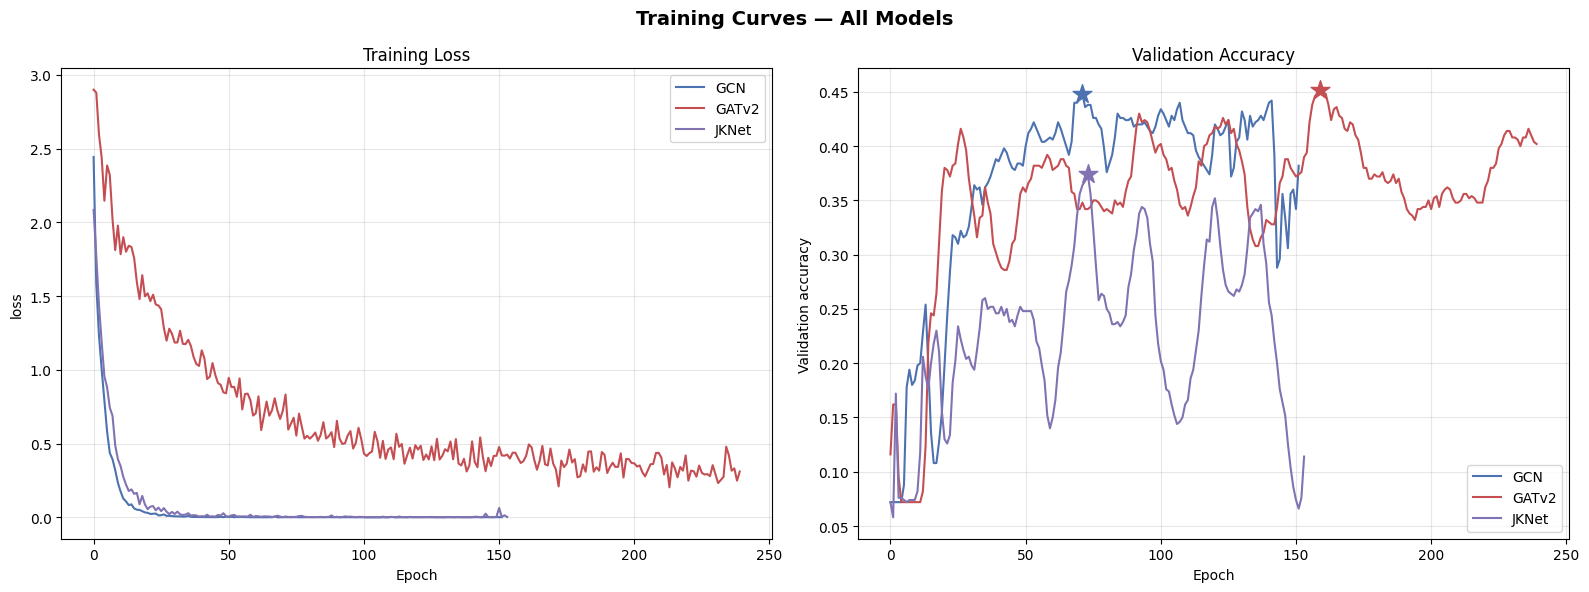

In [ ]:
colors = {"GCN": "#4C72B0", "GATv2": "#C44E52","JKNet": "#8172B2"}
fig,axes = plt.subplots(1,2,figsize=(16,6))
fig.suptitle("Training Curves — All Models", fontsize=14, fontweight="bold")
for name, hist in MODEL_HISTORIES.items():
    axes[0].plot(hist["loss"],    label=name, color=colors[name], linewidth=1.5)
    axes[1].plot(hist["val_acc"], label=name, color=colors[name], linewidth=1.5)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("Training Loss")
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation accuracy")
axes[1].set_title("Validation Accuracy")
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

for name,hist in MODEL_HISTORIES.items():
  best_epoch = int(np.argmax(hist['val_acc']))
  best_val = max(hist['val_acc'])
  axes[1].scatter(best_epoch,best_val,color=colors[name],marker='*',s=200,zorder=5)


plt.tight_layout()
plt.show()

In [ ]:
y_val_true = data.y[data.val_mask].numpy()

In [ ]:
val_preds = {}
val_probs = {}
data = data.to(device)
print("VALIDATION METRICS -> MODEL TRAINED ON FULL FEATURE DATA")
for name, model in TRAINED_MODELS.items():
  model.eval()
  with torch.no_grad():
    logits = model(data.x,data.edge_index)
    probs = F.softmax(logits,dim=1).cpu()
    preds = logits.argmax(dim=1).cpu()
  val_probs[name] = probs
  val_preds[name] = preds[data.val_mask].numpy()
  acc = accuracy_score(y_val_true,val_preds[name])
  print(f"{name} val accuracy = {acc:.4f}")
  print(classification_report(y_val_true,val_preds[name],target_names=[f"C{i}:{CLASS_NAMES[i][:12]}" for i in range(7)],digits=3))

VALIDATION METRICS -> MODEL TRAINED ON FULL FEATURE DATA
GCN val accuracy = 0.4480
                 precision    recall  f1-score   support

  C0:Case Based      0.365     0.443     0.400        61
C1:Genetic Algo      0.556     0.417     0.476        36
C2:Neural Netwo      0.494     0.500     0.497        78
C3:Probabilisti      0.457     0.715     0.558       158
C4:Reinforcemen      0.571     0.198     0.294        81
C5:Rule Learnin      0.421     0.140     0.211        57
      C6:Theory      0.231     0.207     0.218        29

       accuracy                          0.448       500
      macro avg      0.442     0.374     0.379       500
   weighted avg      0.460     0.448     0.421       500

GATv2 val accuracy = 0.4520
                 precision    recall  f1-score   support

  C0:Case Based      0.378     0.279     0.321        61
C1:Genetic Algo      0.538     0.583     0.560        36
C2:Neural Netwo      0.561     0.474     0.514        78
C3:Probabilisti      0.533    

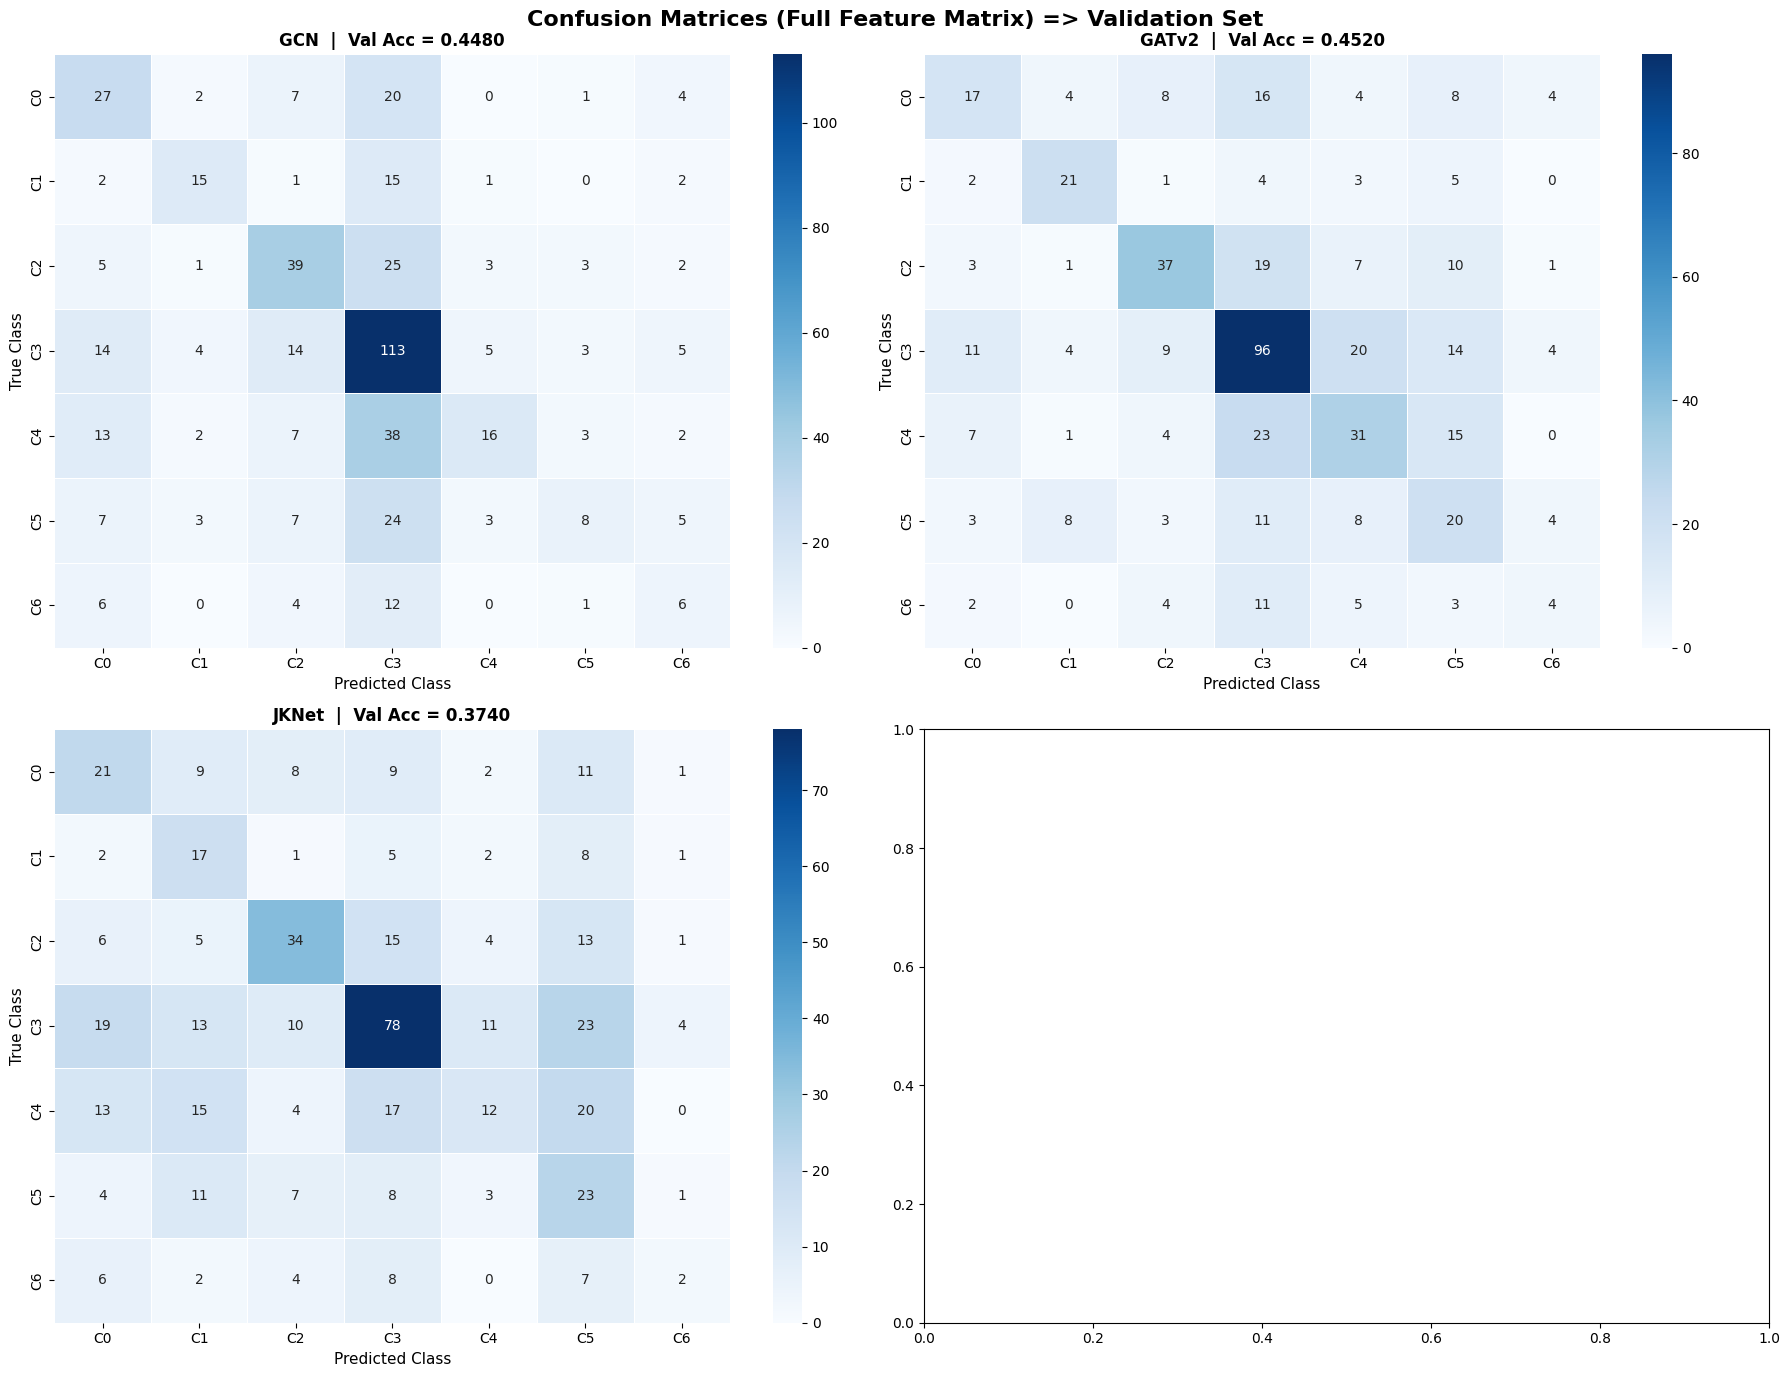

In [ ]:
fig,axes = plt.subplots(2,2,figsize=(18,14))
fig.suptitle("Confusion Matrices (Full Feature Matrix) => Validation Set",fontsize=16,fontweight='bold')
axes = axes.flatten()
for idx,(name,preds) in enumerate(val_preds.items()):
  cm = confusion_matrix(y_val_true,preds)
  acc = accuracy_score(y_val_true,preds)
  short_names = [f"C{i}" for i in range(7)]
  sns.heatmap(cm,ax=axes[idx],annot=True,fmt='d',cmap="Blues",xticklabels=short_names,yticklabels=short_names,linewidth=0.5)
  axes[idx].set_xlabel("Predicted Class",fontsize=11)
  axes[idx].set_ylabel("True Class",fontsize=11)
  axes[idx].set_title(f"{name}  |  Val Acc = {acc:.4f}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:
model_accs = {name:accuracy_score(y_val_true,pred) for name, pred in val_preds.items()}
model_accs

{'GCN': 0.448, 'GATv2': 0.452, 'JKNet': 0.374}

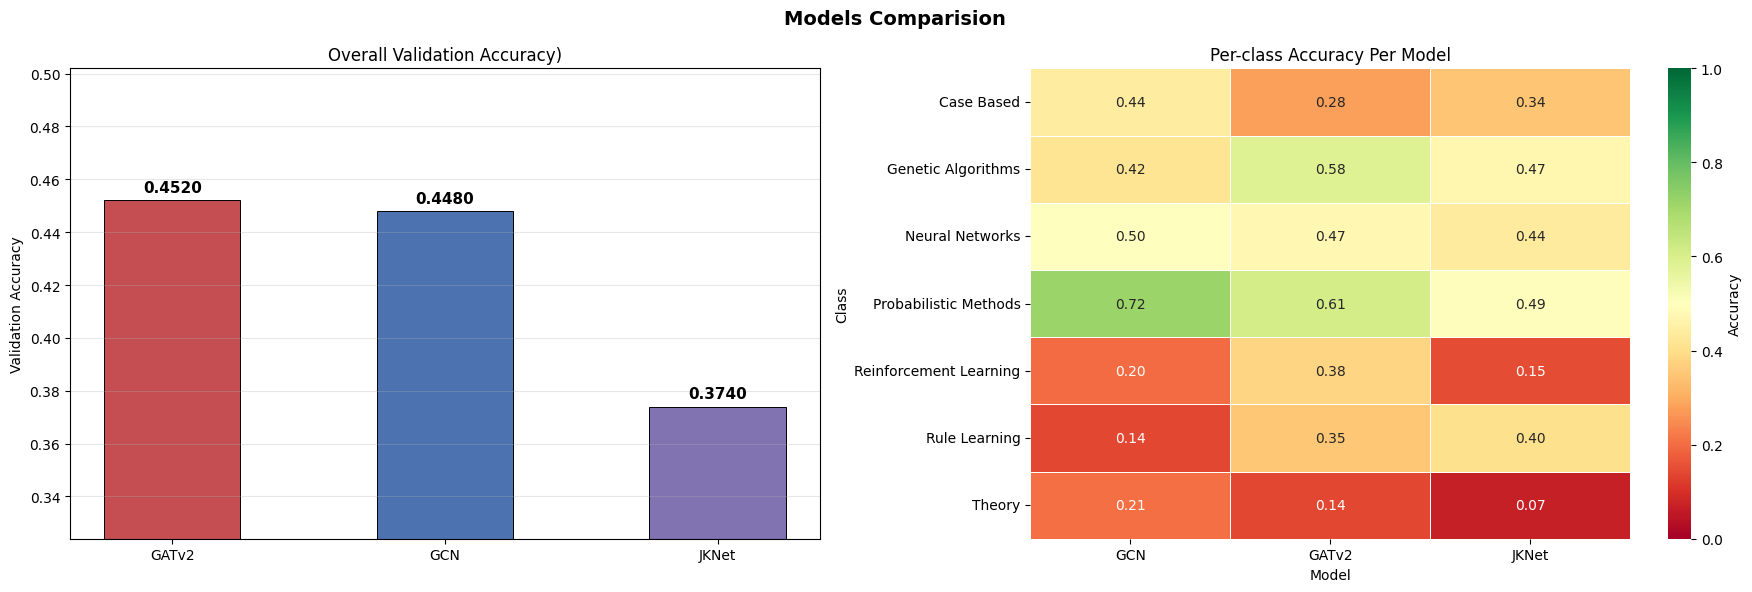

In [ ]:
per_class_acc = {}
for name,preds in val_preds.items():
  cms = confusion_matrix(y_val_true,preds)
  per_class_acc[name] = cms.diagonal() / cms.sum(axis=1)
fig,axes = plt.subplots(1,2,figsize=(18,6))
fig.suptitle("Models Comparision",fontsize=14,fontweight='bold')
ax = axes[0]
names_sorted = sorted(model_accs,key=lambda n: -model_accs[n])
accs_sorted = [model_accs[n] for n in names_sorted]
bar_colors = [colors[n] for n in names_sorted]

bars = ax.bar(names_sorted,accs_sorted,color=bar_colors,edgecolor="black", linewidth=0.7, width=0.5)
ax.set_ylim(min(accs_sorted) - 0.05,min(1.0,max(accs_sorted)+0.05))
ax.set_ylabel("Validation Accuracy")
ax.set_title("Overall Validation Accuracy)")
for bar,acc in zip(bars,accs_sorted):
   ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002, f"{acc:.4f}",
            ha="center", va="bottom", fontweight="bold", fontsize=11)

ax.grid(axis='y',alpha=0.3)
ax = axes[1]
pc_df = pd.DataFrame(per_class_acc,index = [f'{CLASS_NAMES[i]}' for i in range(7)])
sns.heatmap(pc_df,ax=ax,annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=0, vmax=1, linewidths=0.5, cbar_kws={"label": "Accuracy"})
ax.set_title("Per-class Accuracy Per Model")
ax.set_xlabel("Model")
ax.set_ylabel("Class")
plt.tight_layout()
plt.show()

# Low Dimensional Data Phase

GCN


In [ ]:
best_k = 128
best_data = make_denoised_data(data,best_k)

In [ ]:
t0 = time.time()
gcn_model_k, gcn_acc_k, gcn_hist_k, gcn_time_k  = fit_model(GCN(in_dim=best_k,hidden_dim=256, dropout=0.5),
                                                    best_data,epochs=800, lr=0.01, weight_decay=5e-4,
                                                    patience=80,label=f'GCN_{best_k}')

Early stopping at epoch = 97
Best Val accuracy = 0.3780


In [ ]:
torch.save(gcn_model_k.state_dict(), f"best_gcn_{best_k}.pt")

In [ ]:
TRAINED_MODELS[f'GCN_{best_k}'] = gcn_model_k
MODEL_HISTORIES[f"GCN_{best_k}"]  = gcn_hist_k
MODEL_TIMES[f"GCN_{best_k}"]      = gcn_time_k

In [ ]:
print(f"GCN  k = {best_k} | accuarcy = {gcn_acc_k:.4f}  |  time: {gcn_time_k:.0f}s")

GCN  k = 128 | accuarcy = 0.3780  |  time: 9s


GAT

In [ ]:
gat_model_k, gat_acc_k, gat_hist_k, gat_time_k  = fit_model(GAT(in_dim=best_k,hidden_dim=64,out_dim=7, heads=8, dropout=0.6),
                                                    best_data,epochs=800, lr=0.005, weight_decay=5e-4,
                                                    patience=80,label=f'GAT_{best_k}')

epoch = 100 | loss = 1.3284 | val acc = 0.27000001072883606
epoch = 200 | loss = 1.2338 | val acc = 0.32600000500679016
Early stopping at epoch = 277
Best Val accuracy = 0.3340


In [ ]:
torch.save(gat_model_k.state_dict(), f"best_gat_{best_k}.pt")

In [ ]:
TRAINED_MODELS[f"GATv2_{best_k}"]  = gat_model_k
MODEL_HISTORIES[f"GATv2_{best_k}"] = gat_hist_k
MODEL_TIMES[f"GATv2_{best_k}"] = gat_time_k

In [ ]:
print(f"GAT val accuracy:{gat_acc_k:.4f}  |  time: {gat_time_k:.0f}s")

GAT val accuracy:0.3340  |  time: 211s


JKNet

In [ ]:
jk_model_k, jk_acc_k, jk_hist_k, jk_time_k  = fit_model(JKNET(in_dim=best_k,hidden_dim=128,out_dim=7,num_layers=4,dropout=0.5),
                                                best_data,epochs=800, lr=0.01, weight_decay=5e-4,
                                                patience=80,label='JKNet')

epoch = 100 | loss = 0.0035 | val acc = 0.31200000643730164
Early stopping at epoch = 110
Best Val accuracy = 0.3320


In [ ]:
torch.save(jk_model_k.state_dict(), f"best_jknet_{best_k}.pt")

In [ ]:
TRAINED_MODELS[f"JKNet_{best_k}"] = jk_model_k
MODEL_HISTORIES[f"JKNet_{best_k}"] = jk_hist_k
MODEL_TIMES[f"JKNet_{best_k}"] = jk_time_k

In [ ]:
print(f"JKNet val accuracy:{jk_acc_k:.4f}  |  time: {jk_time_k:.0f}s")

JKNet val accuracy:0.3320  |  time: 21s


# Training Curves

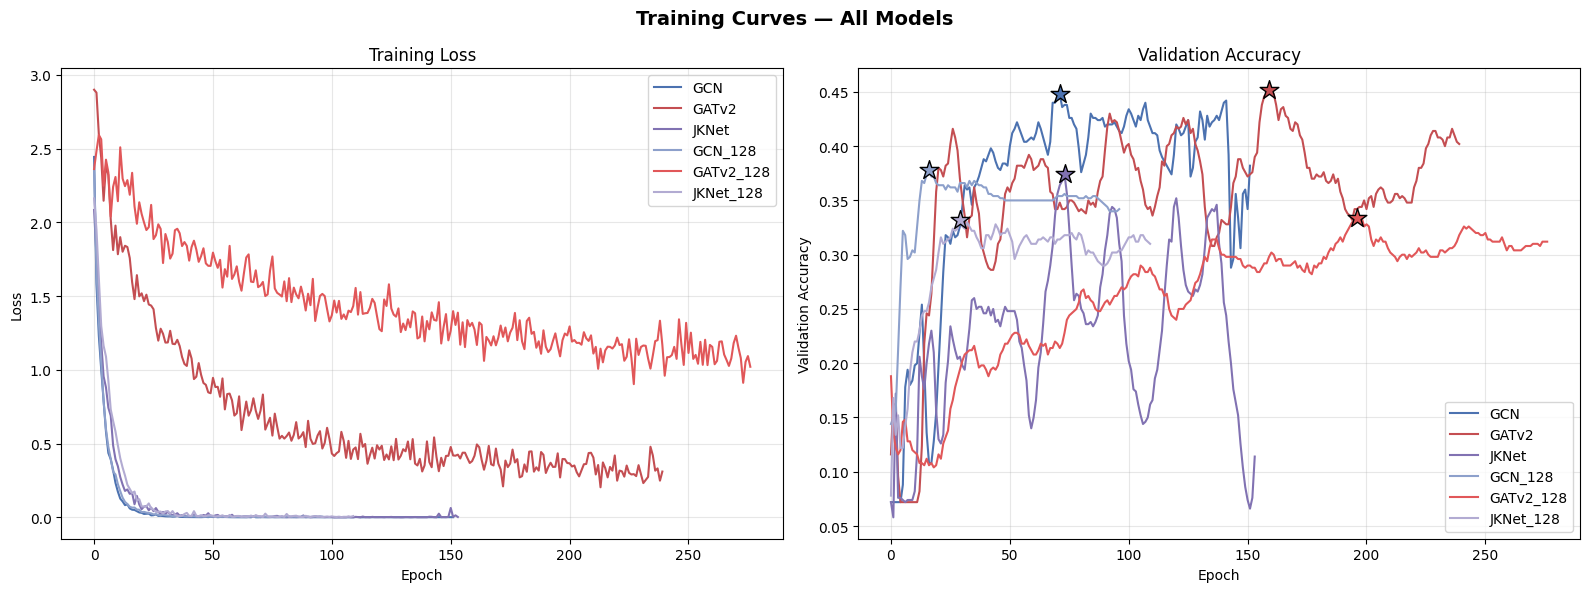

In [ ]:
colors = {
    "GCN": "#4C72B0",
    "GATv2": "#C44E52",
    "JKNet": "#8172B2",
    f"GCN_{best_k}": "#8DA0CB",
    f"GATv2_{best_k}": "#E15759",
    f"JKNet_{best_k}": "#B2ABD2"
}
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Training Curves — All Models", fontsize=14, fontweight="bold")

for name, hist in MODEL_HISTORIES.items():
    axes[0].plot(hist["loss"], label=name, color=colors[name], linewidth=1.5)
    axes[1].plot(hist["val_acc"], label=name, color=colors[name], linewidth=1.5)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Accuracy")
axes[1].set_title("Validation Accuracy")
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

for name, hist in MODEL_HISTORIES.items():
    best_epoch = int(np.argmax(hist['val_acc']))
    best_val = max(hist['val_acc'])
    axes[1].scatter(best_epoch, best_val, color=colors[name], marker='*', s=200, zorder=5, edgecolors='black')

plt.tight_layout()
plt.show()

In [ ]:
y_val_true = best_data.y[best_data.val_mask].numpy()

In [ ]:
TRAINED_MODELS.items()

dict_items([('GCN', GCN(
  (conv1): GCNConv(1433, 256)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): GCNConv(256, 7)
)), ('GATv2', GAT(
  (conv1): GATv2Conv(1433, 64, heads=8)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): GATv2Conv(512, 7, heads=1)
)), ('JKNet', JKNET(
  (convs): ModuleList(
    (0): GCNConv(1433, 128)
    (1-3): 3 x GCNConv(128, 128)
  )
  (bns): ModuleList(
    (0-3): 4 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (jk): JumpingKnowledge(max)
  (lin): Linear(in_features=128, out_features=7, bias=True)
)), ('GCN_128', GCN(
  (conv1): GCNConv(128, 256)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): GCNConv(256, 7)
)), ('GATv2_128', GAT(
  (conv1): GATv2Conv(128, 64, heads=8)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

In [ ]:
val_preds = {}
val_probs = {}
best_data = best_data.to(device)
print("VALIDATION METRICS -> MODEL TRAINED ON REDUCED FEATURE DATA")
for name,model in TRAINED_MODELS.items():
  model.eval()
  if "_128" in name:
    current_x = best_data.x
    current_edge_index = best_data.edge_index
    with torch.no_grad():
      logits = model(current_x,current_edge_index)
      probs = F.softmax(logits,dim=1).cpu()
      val_logits = logits[best_data.val_mask]
      preds = val_logits.argmax(dim=1).cpu().numpy()
    val_probs[name] = probs.numpy()
    val_preds[name] = preds
    acc = accuracy_score(y_val_true, preds)
    print(f"Model: {name}")
    print(f"Validation Acc = {acc}")
    print(classification_report(
        y_val_true,
        preds,
        target_names=[f"C{i}: {CLASS_NAMES[i][:12]}" for i in range(7)],
        digits=3
    ))

VALIDATION METRICS -> MODEL TRAINED ON REDUCED FEATURE DATA
Model: GCN_128
Validation Acc = 0.378
                  precision    recall  f1-score   support

  C0: Case Based      0.306     0.361     0.331        61
C1: Genetic Algo      0.279     0.667     0.393        36
C2: Neural Netwo      0.521     0.487     0.503        78
C3: Probabilisti      0.630     0.291     0.398       158
C4: Reinforcemen      0.467     0.346     0.397        81
C5: Rule Learnin      0.309     0.298     0.304        57
      C6: Theory      0.173     0.483     0.255        29

        accuracy                          0.378       500
       macro avg      0.383     0.419     0.369       500
    weighted avg      0.459     0.378     0.387       500

Model: GATv2_128
Validation Acc = 0.334
                  precision    recall  f1-score   support

  C0: Case Based      0.397     0.443     0.419        61
C1: Genetic Algo      0.261     0.806     0.395        36
C2: Neural Netwo      0.429     0.538     0.47

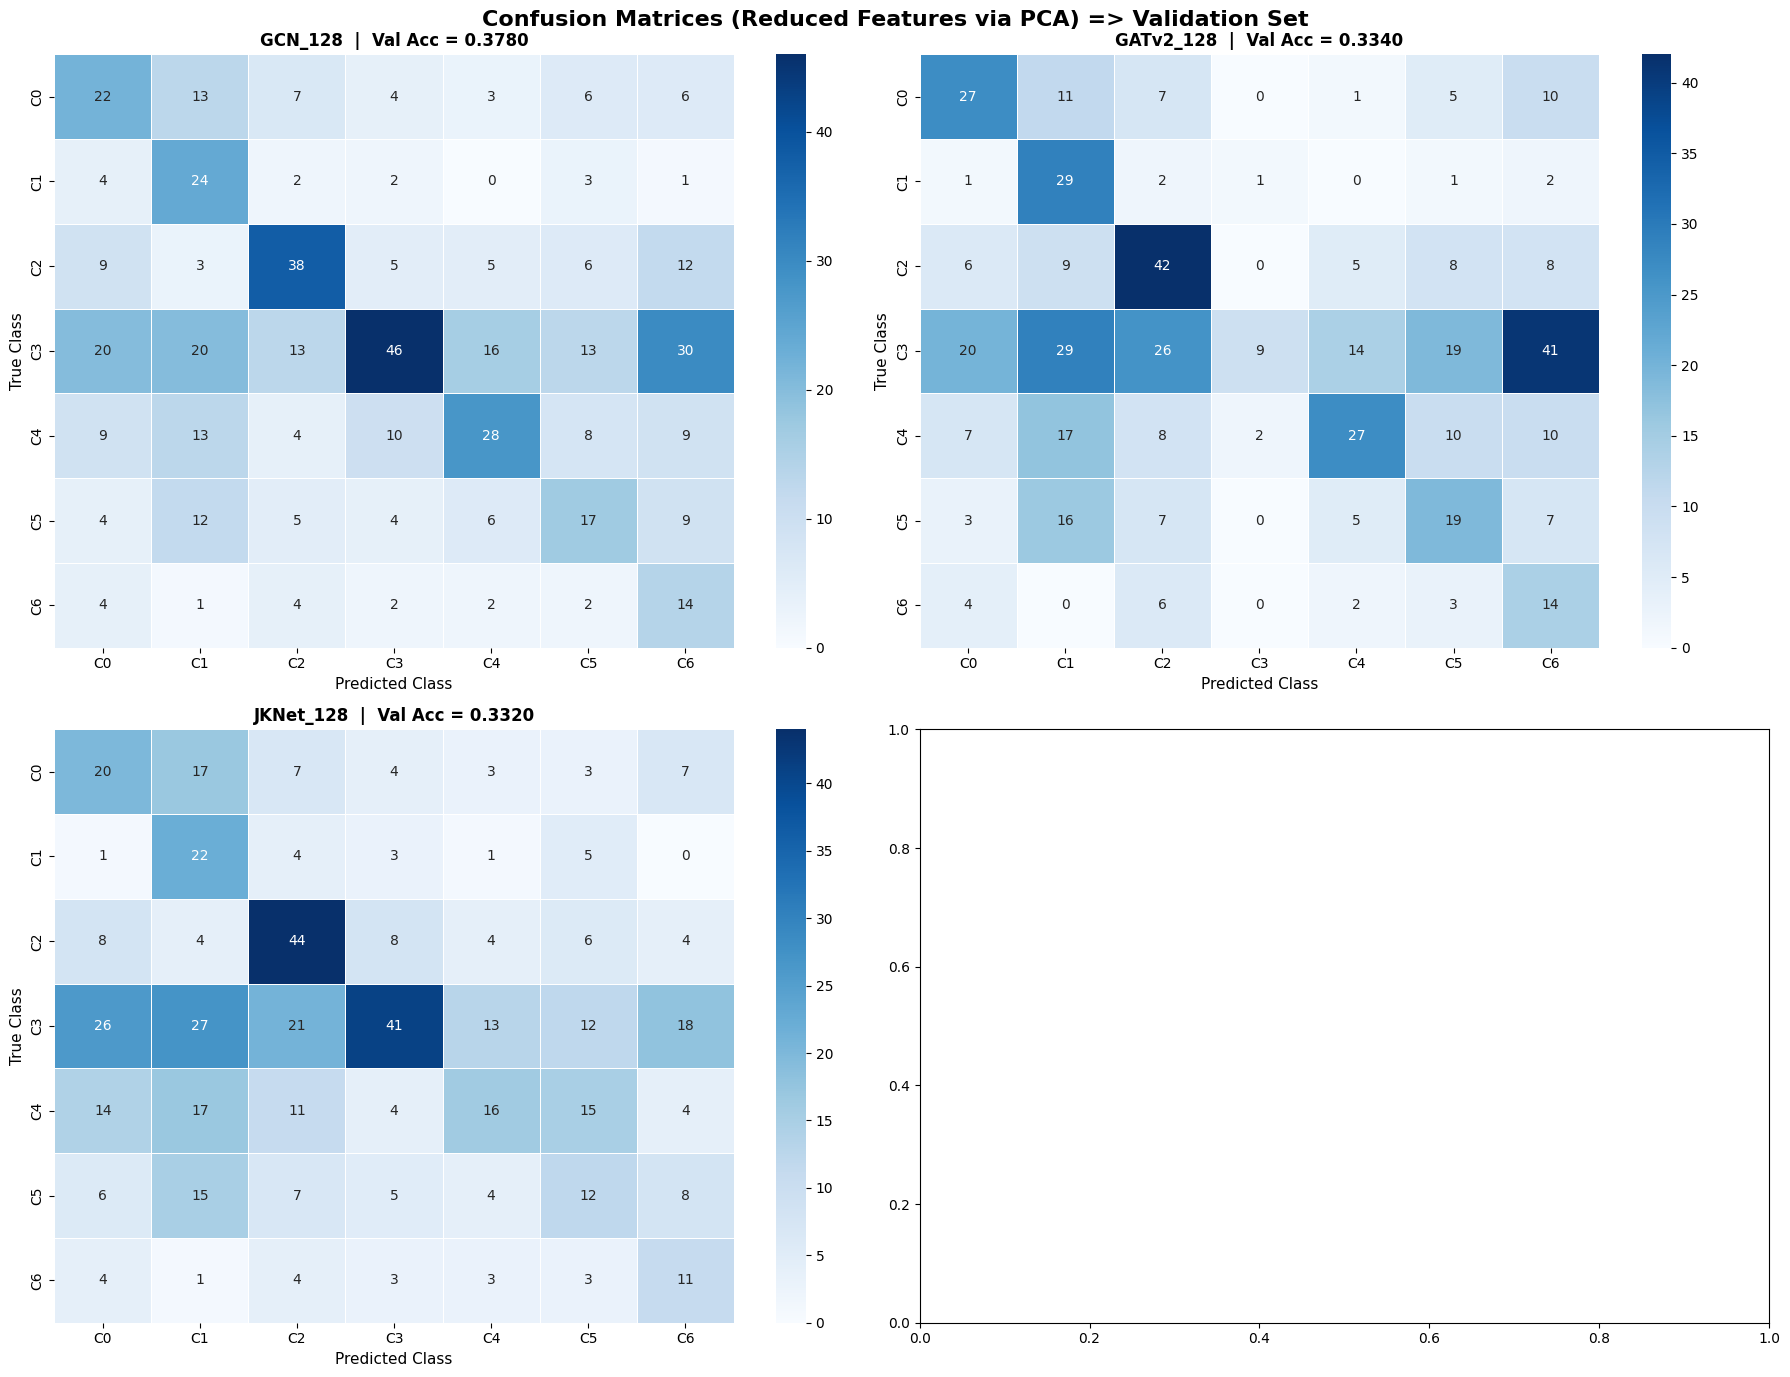

In [ ]:
fig,axes = plt.subplots(2,2,figsize=(18,14))
fig.suptitle("Confusion Matrices (Reduced Features via PCA) => Validation Set",fontsize=16,fontweight='bold')
axes = axes.flatten()
for idx,(name,preds) in enumerate(val_preds.items()):
  cm = confusion_matrix(y_val_true,preds)
  acc = accuracy_score(y_val_true,preds)
  short_names = [f"C{i}" for i in range(7)]
  sns.heatmap(cm,ax=axes[idx],annot=True,fmt='d',cmap="Blues",xticklabels=short_names,yticklabels=short_names,linewidth=0.5)
  axes[idx].set_xlabel("Predicted Class",fontsize=11)
  axes[idx].set_ylabel("True Class",fontsize=11)
  axes[idx].set_title(f"{name}  |  Val Acc = {acc:.4f}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:
model_accs_k = {name:accuracy_score(y_val_true,pred) for name, pred in val_preds.items()}
model_accs_k

{'GCN_128': 0.378, 'GATv2_128': 0.334, 'JKNet_128': 0.332}

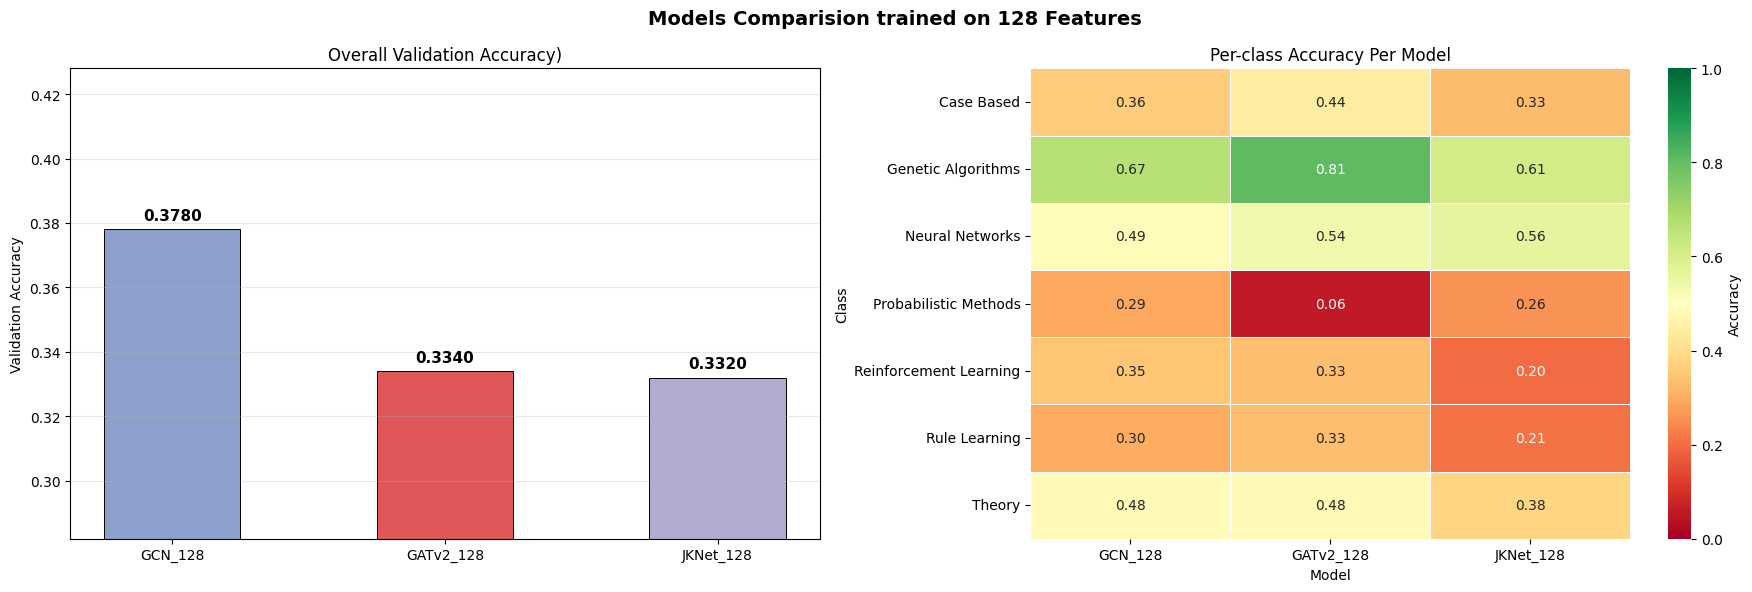

In [ ]:
per_class_acc = {}
for name,preds in val_preds.items():
  cms = confusion_matrix(y_val_true,preds)
  per_class_acc[name] = cms.diagonal() / cms.sum(axis=1)
fig,axes = plt.subplots(1,2,figsize=(18,6))
fig.suptitle(f"Models Comparision trained on {best_k} Features",fontsize=14,fontweight='bold')
ax = axes[0]
names_sorted = sorted(model_accs_k,key=lambda n: -model_accs_k[n])
accs_sorted = [model_accs_k[n] for n in names_sorted]
bar_colors = [colors[n] for n in names_sorted]

bars = ax.bar(names_sorted,accs_sorted,color=bar_colors,edgecolor="black", linewidth=0.7, width=0.5)
ax.set_ylim(min(accs_sorted) - 0.05,min(1.0,max(accs_sorted)+0.05))
ax.set_ylabel("Validation Accuracy")
ax.set_title("Overall Validation Accuracy)")
for bar,acc in zip(bars,accs_sorted):
   ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002, f"{acc:.4f}",
            ha="center", va="bottom", fontweight="bold", fontsize=11)

ax.grid(axis='y',alpha=0.3)
ax = axes[1]
pc_df = pd.DataFrame(per_class_acc,index = [f'{CLASS_NAMES[i]}' for i in range(7)])
sns.heatmap(pc_df,ax=ax,annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=0, vmax=1, linewidths=0.5, cbar_kws={"label": "Accuracy"})
ax.set_title("Per-class Accuracy Per Model")
ax.set_xlabel("Model")
ax.set_ylabel("Class")
plt.tight_layout()
plt.show()

# ENSEMBLE

In [ ]:
full_model_info = {
    "GCN":(TRAINED_MODELS['GCN'],0.4480),
    "GATv2":(TRAINED_MODELS['GATv2'],0.4520),
    "JKNet": (TRAINED_MODELS["JKNet"],0.3740),
}

In [ ]:
accs = [a for model,a in full_model_info.values()]
weights = np.exp(accs * 10)
weights = weights / weights.sum()

In [ ]:
ensemble_probs = None

In [ ]:
for (name,(model,acc)),w in zip(full_model_info.items(),weights):
  model.eval()
  with torch.no_grad():
    logits = model(data.x, data.edge_index)
    probs  = F.softmax(logits, dim=1).cpu()
  ensemble_probs = probs * w if ensemble_probs is None else ensemble_probs + probs * w
  print(f"model = {name} | val acc = {acc} |  weight = {w}")

y_val_true  = data.y.cpu()[data.val_mask.cpu()].numpy()
ens_val_preds = ensemble_probs.argmax(dim=1)[data.val_mask.cpu()].numpy()
ens_acc = accuracy_score(y_val_true, ens_val_preds)

print(f"Ensemble val_accuracy = {ens_acc:.4f}")
print(f"\n Classification report of ensemble ")
print(classification_report(y_val_true,ens_val_preds,target_names=[f"C{i}:{CLASS_NAMES[i][:12]}" for i in range(7)],digits=3))

model = GCN | val acc = 0.448 |  weight = 0.03409850719324088
model = GATv2 | val acc = 0.452 |  weight = 0.034235174374152806
model = JKNet | val acc = 0.374 |  weight = 0.03166631843260632
Ensemble val_accuracy = 0.4460

 Classification report of ensemble 
                 precision    recall  f1-score   support

  C0:Case Based      0.361     0.361     0.361        61
C1:Genetic Algo      0.438     0.583     0.500        36
C2:Neural Netwo      0.507     0.474     0.490        78
C3:Probabilisti      0.515     0.639     0.571       158
C4:Reinforcemen      0.457     0.259     0.331        81
C5:Rule Learnin      0.283     0.298     0.291        57
      C6:Theory      0.250     0.138     0.178        29

       accuracy                          0.446       500
      macro avg      0.401     0.393     0.389       500
   weighted avg      0.438     0.446     0.434       500



We will choose the GATv2 because it has highest accuracy

In [406]:
gat_model_ref = TRAINED_MODELS["GATv2"]
gat_model_ref.eval()
with torch.no_grad():
  gat_logits = gat_model_ref(data.x,data.edge_index)
  final_probs = F.softmax(logits,dim=1).cpu()
submit_label = "GATv2_full_features"

In [407]:
final_preds   = final_probs.argmax(dim=1)
test_ids_np   = data.test_ids.cpu().numpy()
test_preds_np = final_preds[data.test_mask.cpu()].numpy()

In [408]:
submission_df = pd.DataFrame({
    "id":     test_ids_np,
    "target": test_preds_np
})

In [409]:
submission_df.head()

,id,target
0,1708,0
1,1709,2
2,1710,2
3,1711,2
4,1712,0


In [411]:
submission_df.to_csv("submission.csv", index=False)

In [ ]:
TOTAL_TIME = time.time() - START_TIME
print(f"TOTAL_TIME = {TOTAL_TIME:.0f}s ")

TOTAL_TIME = 667s 
